#문제 정의
* input data : length, diameter, height, whole weight, shucked weight, viecera weight, shell weight, (water, volume, round, generation)
* output data : Target(age)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kurtosis, skew
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.simplefilter(action='ignore', category = FutureWarning)
import joblib

In [53]:
train = pd.read_csv('./train2.csv')
#pandas의 dataframe 형식으로 불러오기

In [54]:
train.head()

,id,Gender,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
0,1,M,0.605,0.470,0.115,1.1140,0.3925,0.2910,0.3100,15
1,2,I,0.430,0.315,0.095,0.3780,0.1750,0.0800,0.1045,8
2,3,I,0.580,0.490,0.195,1.3165,0.5305,0.2540,0.4100,18
3,4,M,0.535,0.405,0.175,1.2705,0.5480,0.3265,0.3370,13
4,5,I,0.310,0.235,0.090,0.1270,0.0480,0.0310,0.0400,6


In [55]:
train.shape
#row col

(1253, 10)

In [56]:
#data들의 자료형
tcolumns = train.columns[:]
for i in range(10):
  print(tcolumns[i], ':', train[tcolumns[i]].dtype)

id : int64
Gender : str
Lenght : float64
Diameter : float64
Height : float64
Whole Weight : float64
Shucked Weight : float64
Viscra Weight : float64
Shell Weight : float64
Target : int64


gender만 categorical
나머지는 numerical type

In [57]:
#각 feature에서의 unique의 개수
for i in range(10):
  print(tcolumns[i],':',train[tcolumns[i]].nunique())


id : 1253
Gender : 3
Lenght : 125
Diameter : 100
Height : 44
Whole Weight : 1048
Shucked Weight : 863
Viscra Weight : 638
Shell Weight : 538
Target : 22


In [58]:

print(train.groupby('id').count().iloc[:,0])
#unnamed = id -1 관계 필요 없음

id
1       1
2       1
3       1
4       1
5       1
       ..
1249    1
1250    1
1251    1
1252    1
1253    1
Name: Gender, Length: 1253, dtype: int64


In [59]:
train = train.drop(columns=['id'])

#필요없는 feature 삭제

In [60]:
numerical_features = train.select_dtypes(include = [np.number]).columns
categorical_features = train.select_dtypes(include = [object]).columns

In [61]:
def check_missing_col(dataframe):
  missing_col = []
  counted_missing_col = 0
  for i,col in enumerate(dataframe.columns):
    missing_values = sum(dataframe[col].isna())
    is_missing = True if missing_values >= 1 else False
    if is_missing:
      counted_missing_col += 1
      print(f'결측치가 있는 col은 : {col}입니다')
      print(f'해당 col에 총 {missing_values}개의 결측치가 존재합니다')
      missing_col.append([col,dataframe[col].dtype])
  if counted_missing_col ==0:
    print('결측치가 존재 X')
  return missing_col

missing_col = check_missing_col(train)
#결측치가 존재하지 않으면 좋은데 존재할 경우
#결측치 분포나 갯수를 보고 삭제, 무시 또는 삽입을 해야됨

결측치가 존재 X


In [62]:
train.head()

,Gender,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
0,M,0.605,0.470,0.115,1.1140,0.3925,0.2910,0.3100,15
1,I,0.430,0.315,0.095,0.3780,0.1750,0.0800,0.1045,8
2,I,0.580,0.490,0.195,1.3165,0.5305,0.2540,0.4100,18
3,M,0.535,0.405,0.175,1.2705,0.5480,0.3265,0.3370,13
4,I,0.310,0.235,0.090,0.1270,0.0480,0.0310,0.0400,6


In [63]:
train.describe()

,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
count,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000
mean,0.522869,0.406963,0.139545,0.831199,0.358818,0.181006,0.240077,9.912211
std,0.120231,0.099771,0.039033,0.500491,0.224612,0.111936,0.142574,3.214676
min,0.110000,0.090000,0.030000,0.008000,0.002500,0.002000,0.003000,3.000000
25%,0.445000,0.345000,0.115000,0.440500,0.182500,0.092500,0.130000,8.000000
50%,0.535000,0.420000,0.140000,0.777500,0.326000,0.168000,0.230000,10.000000
75%,0.615000,0.480000,0.165000,1.160000,0.505500,0.256500,0.330000,11.000000
max,0.780000,0.630000,0.250000,2.779500,1.488000,0.760000,1.005000,29.000000


In [64]:
temp = train['Target'].unique()
np.sort(temp)
#target 나이의 분포

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 29])

In [65]:
train.groupby('Target').count().iloc[:,0]
# 나이별 전복의 개수
#,0은 열 하나의 결과만 출력

Target
3       5
4      14
5      37
6      88
7     107
8     174
9     200
10    202
11    141
12     79
13     62
14     42
15     26
16     21
17     13
18     12
19      8
20     11
21      5
22      2
23      3
29      1
Name: Gender, dtype: int64

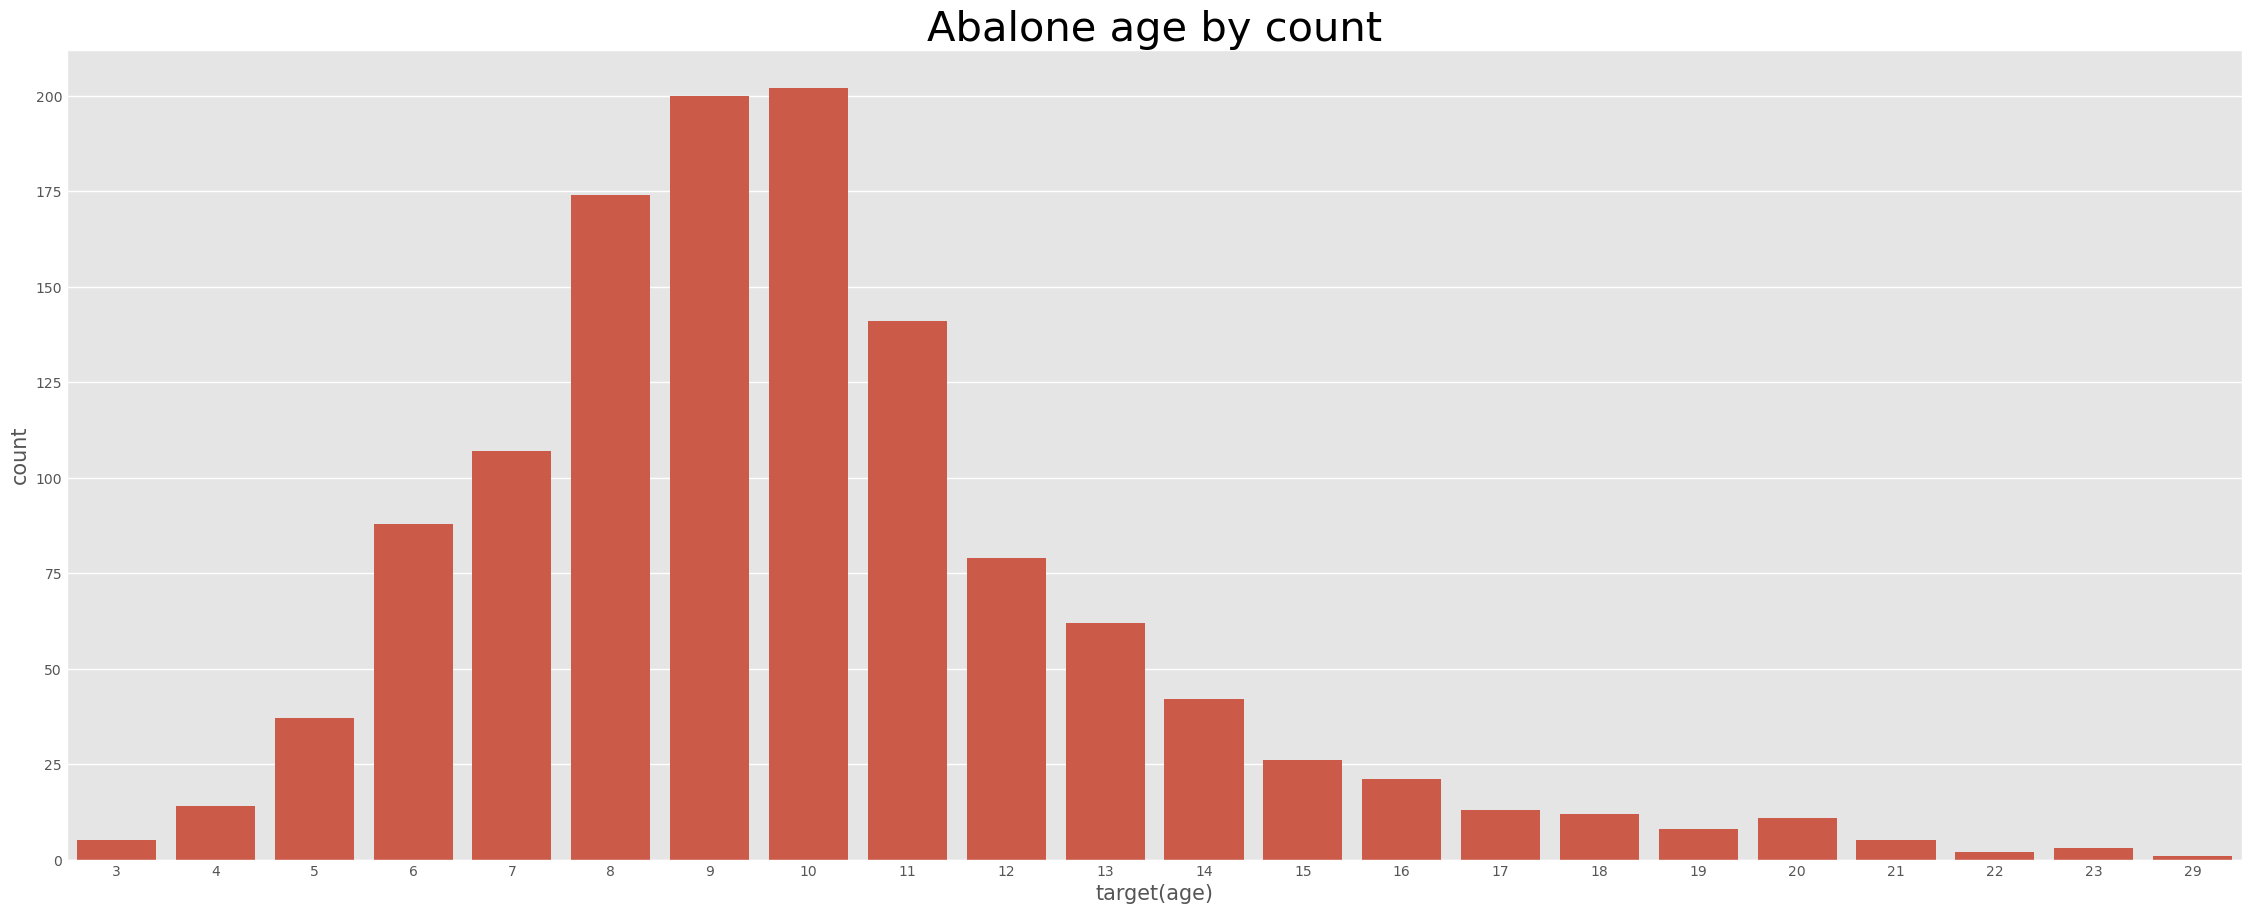

In [66]:
plt.rcParams['figure.figsize'] = [25,10]
sns.countplot(x='Target', data=train) #train 파일에서 target의 count
plt.title('Abalone age by count', fontsize = 30)
plt.xlabel('target(age)', fontsize = 15)
plt.ylabel('count', fontsize = 15)
plt.show()

In [67]:
#백분위수 구하기
print(train.Target.quantile(.25))
print(train.Target.quantile(.50))
print(train.Target.quantile(.75))

8.0
10.0
11.0


8 ~ 11에 몰려있음

In [68]:
print(skew(train.Target)) #왜도 값이 양수 -> 평균이 정규분포의 평균보다 왼쪽에 치우쳐짐
print(kurtosis(train.Target, fisher = True)) #정규분포의 첨도가 0일 때

1.150866334060245
2.5227266204906273


In [69]:
temp1 = train['Target'] == 29
temp2 = train['Target'] == 23
train[temp1 | temp2]

,Gender,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
553,F,0.45,0.380,0.165,0.8165,0.2500,0.1915,0.265,23
762,F,0.70,0.585,0.185,1.8075,0.7055,0.3215,0.475,29
1131,F,0.55,0.415,0.135,0.7750,0.3020,0.1790,0.260,23
1234,F,0.49,0.385,0.150,0.7865,0.2410,0.1400,0.240,23


In [70]:
temp3 = train['Target'] == 3
temp4 = train['Target'] == 4
train[temp3 | temp4]

,Gender,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
20,M,0.155,0.110,0.040,0.0155,0.0065,0.0030,0.0050,3
73,I,0.245,0.180,0.065,0.0710,0.0300,0.0130,0.0215,4
92,I,0.155,0.105,0.050,0.0175,0.0050,0.0035,0.0050,4
180,I,0.200,0.145,0.060,0.0370,0.0125,0.0095,0.0110,4
206,I,0.200,0.150,0.040,0.0460,0.0210,0.0070,0.0065,4
210,I,0.195,0.150,0.045,0.0375,0.0180,0.0060,0.0110,3
233,I,0.255,0.195,0.055,0.0725,0.0285,0.0170,0.0210,4
285,I,0.130,0.100,0.030,0.0130,0.0045,0.0030,0.0040,3
463,I,0.110,0.090,0.030,0.0080,0.0025,0.0020,0.0030,3
526,I,0.360,0.270,0.085,0.1960,0.0875,0.0350,0.0640,4


이 data에서 나이가 어린 개체와 많은 개체 사이의 눈에 띄는 차이점은 성별

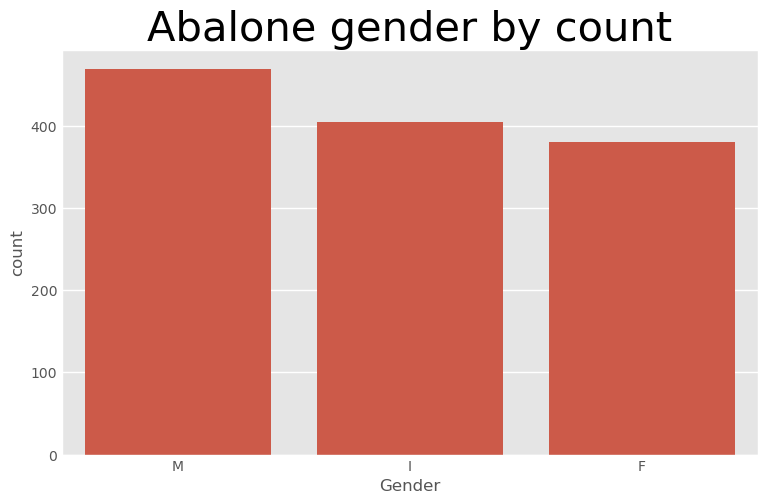

In [71]:
plt.rcParams['figure.figsize'] = [8,5]
sns.countplot(x='Gender', data=train)
plt.title('Abalone gender by count', fontsize = 30)
plt.show()

이 data에서는 성별의 분포가 고른 편

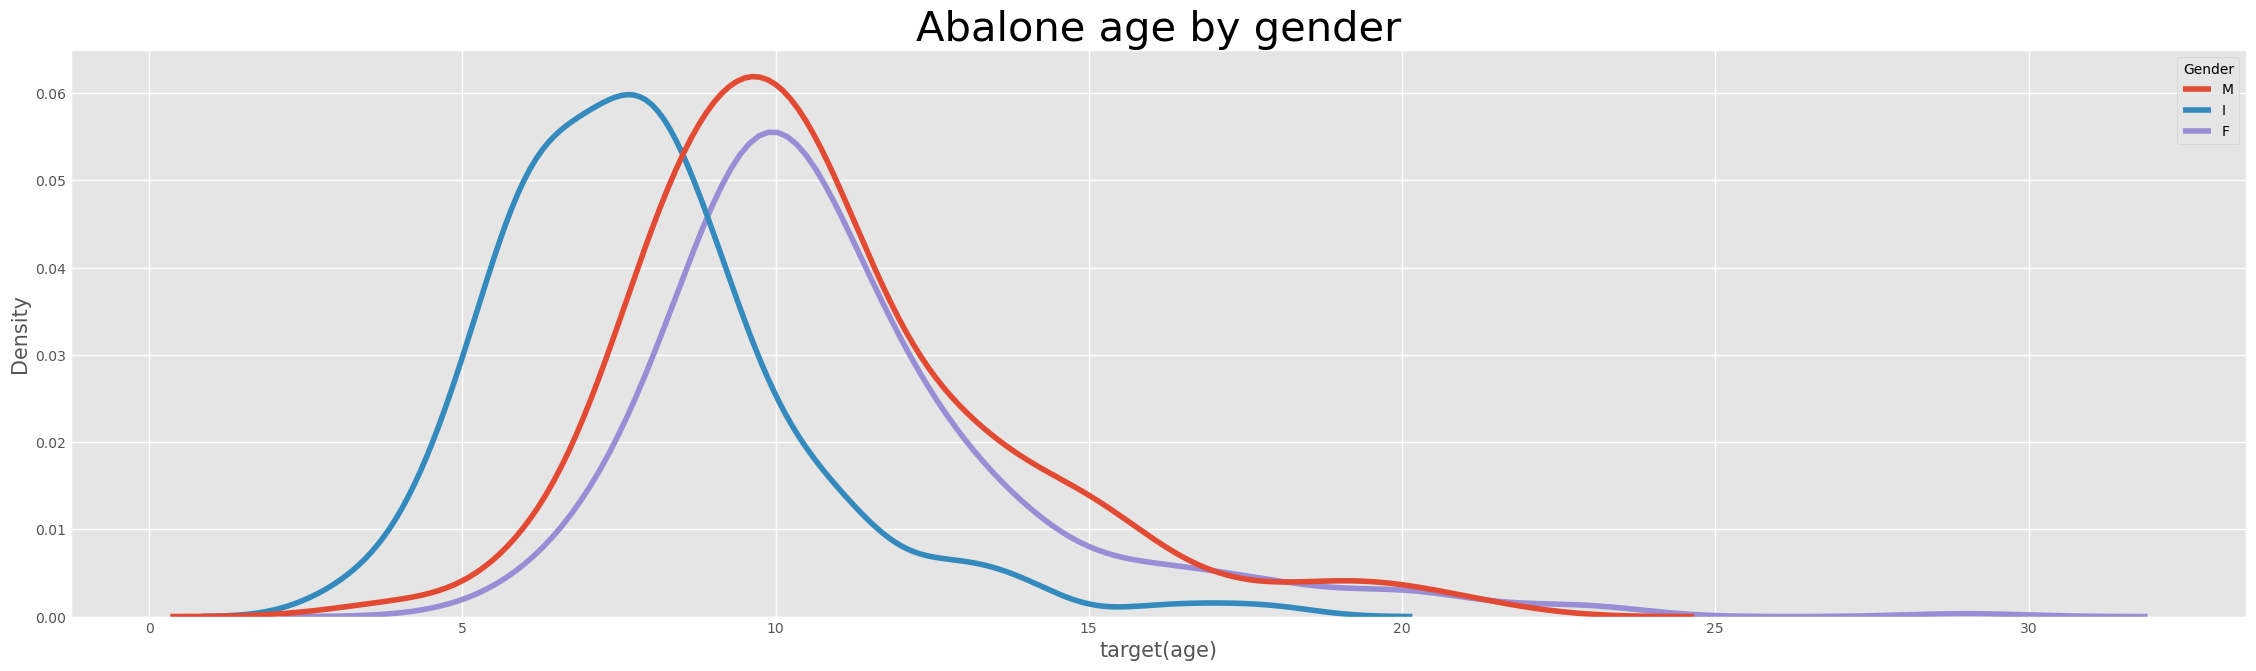

In [72]:
plt.rcParams['figure.figsize'] = [25,7]
sns.kdeplot(x='Target', hue='Gender', data=train)
plt.title('Abalone age by gender', fontsize = 30)
plt.xlabel('target(age)', fontsize = 15)
plt.ylabel('Density', fontsize = 15) #밀도
plt.show()

<Axes: xlabel='Gender', ylabel='Target'>

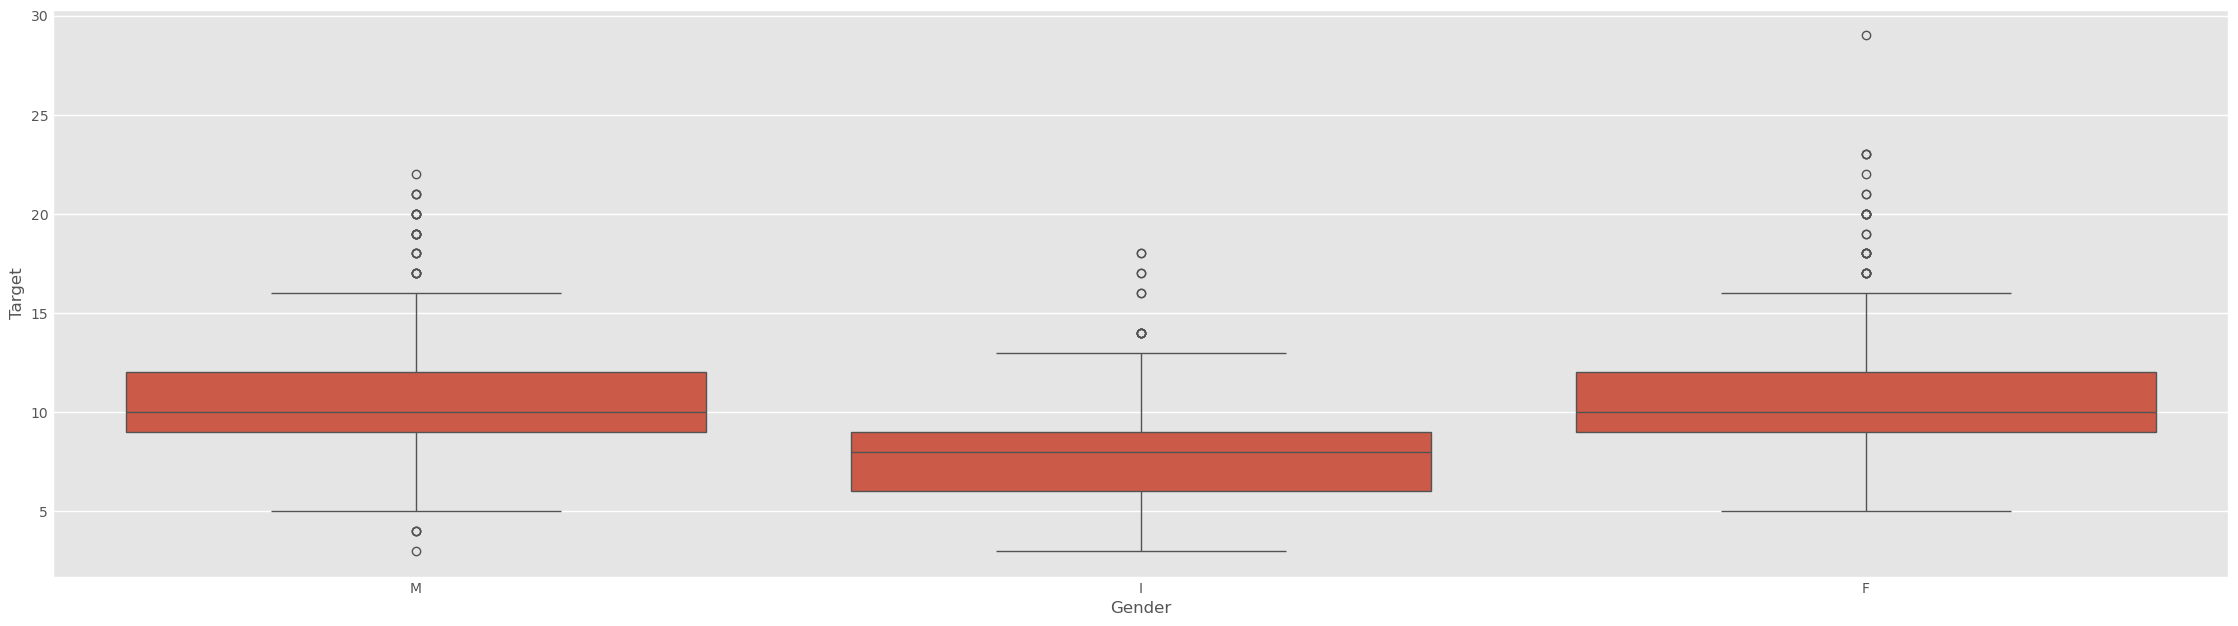

In [73]:
sns.boxplot(x = 'Gender', y = 'Target', data = train)

데이터에서 gender I는 M과 F에 비해 나이가 어린 곳에서 밀도가 높게 형성..

F의 성별이 나머지 성별보다 나이가 많은 곳에서 밀도가 높게 형성

In [74]:
train.groupby('Gender').Target.describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,380.0,11.086842,3.171498,5.0,9.0,10.0,12.0,29.0
I,404.0,7.876238,2.395100,3.0,6.0,8.0,9.0,18.0
M,469.0,10.714286,3.036007,3.0,9.0,10.0,12.0,22.0


성별에 따른 target의 describe 호출

In [75]:
data_description = train.describe()
data_description

,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
count,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000
mean,0.522869,0.406963,0.139545,0.831199,0.358818,0.181006,0.240077,9.912211
std,0.120231,0.099771,0.039033,0.500491,0.224612,0.111936,0.142574,3.214676
min,0.110000,0.090000,0.030000,0.008000,0.002500,0.002000,0.003000,3.000000
25%,0.445000,0.345000,0.115000,0.440500,0.182500,0.092500,0.130000,8.000000
50%,0.535000,0.420000,0.140000,0.777500,0.326000,0.168000,0.230000,10.000000
75%,0.615000,0.480000,0.165000,1.160000,0.505500,0.256500,0.330000,11.000000
max,0.780000,0.630000,0.250000,2.779500,1.488000,0.760000,1.005000,29.000000


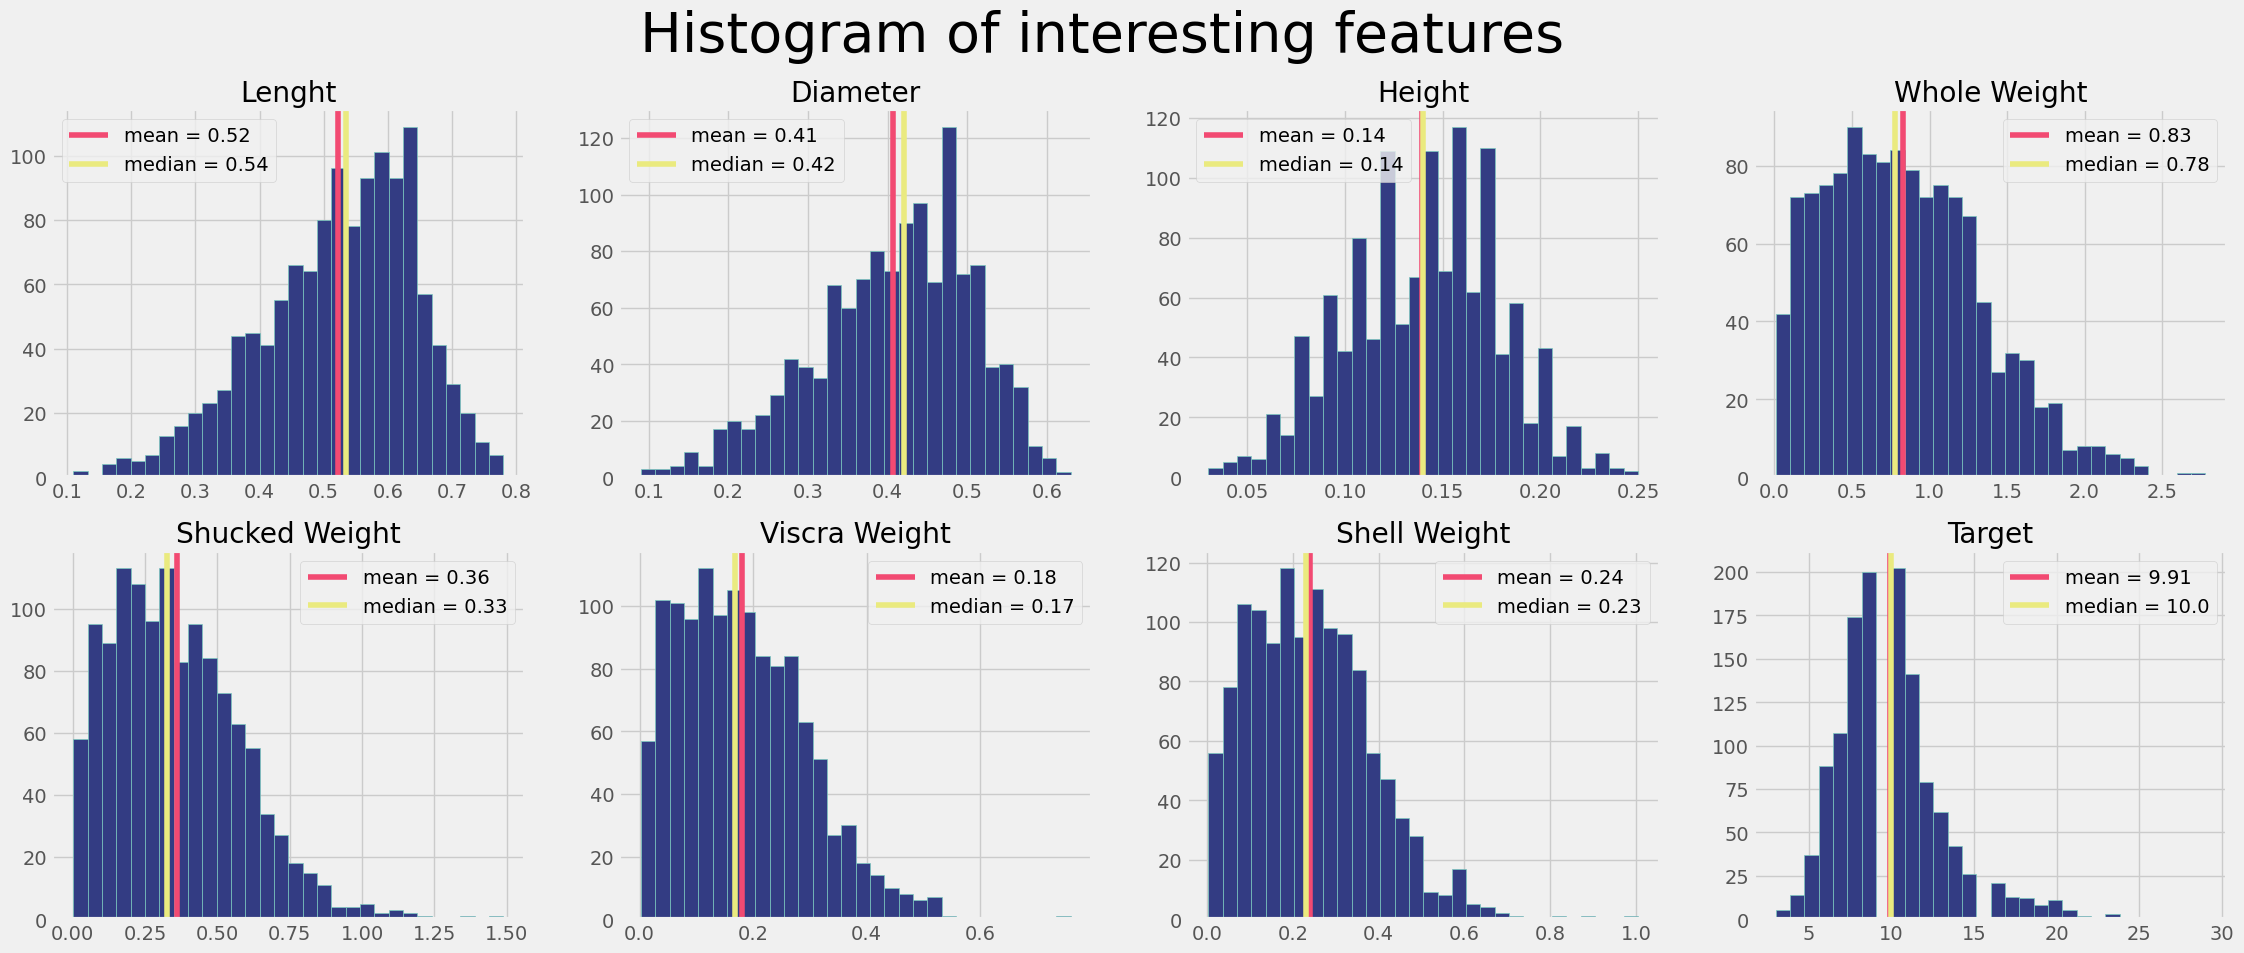

In [76]:
interest_columns = train.columns[1:]
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(2,4, figsize =(25, 10))
fig.suptitle('Histogram of interesting features', fontsize = 40)
column_idx =0
for i in range(2):
  for j in range(4):
    ax[i][j].hist(train[interest_columns[column_idx]], bins = 30, color = '#333C83', edgecolor = '#7bcabf')
    ax[i][j].set_title(interest_columns[column_idx])
    ax[i][j].axvline(data_description[interest_columns[column_idx]]['mean'], c = '#F24A72', label = f"mean = {round(data_description[interest_columns[column_idx]]['mean'], 2)}")
    ax[i][j].axvline(data_description[interest_columns[column_idx]]['50%'], c = '#EAEA7F', label = f"median = {round(data_description[interest_columns[column_idx]]['50%'], 2)}")
    ax[i][j].legend()
    column_idx += 1

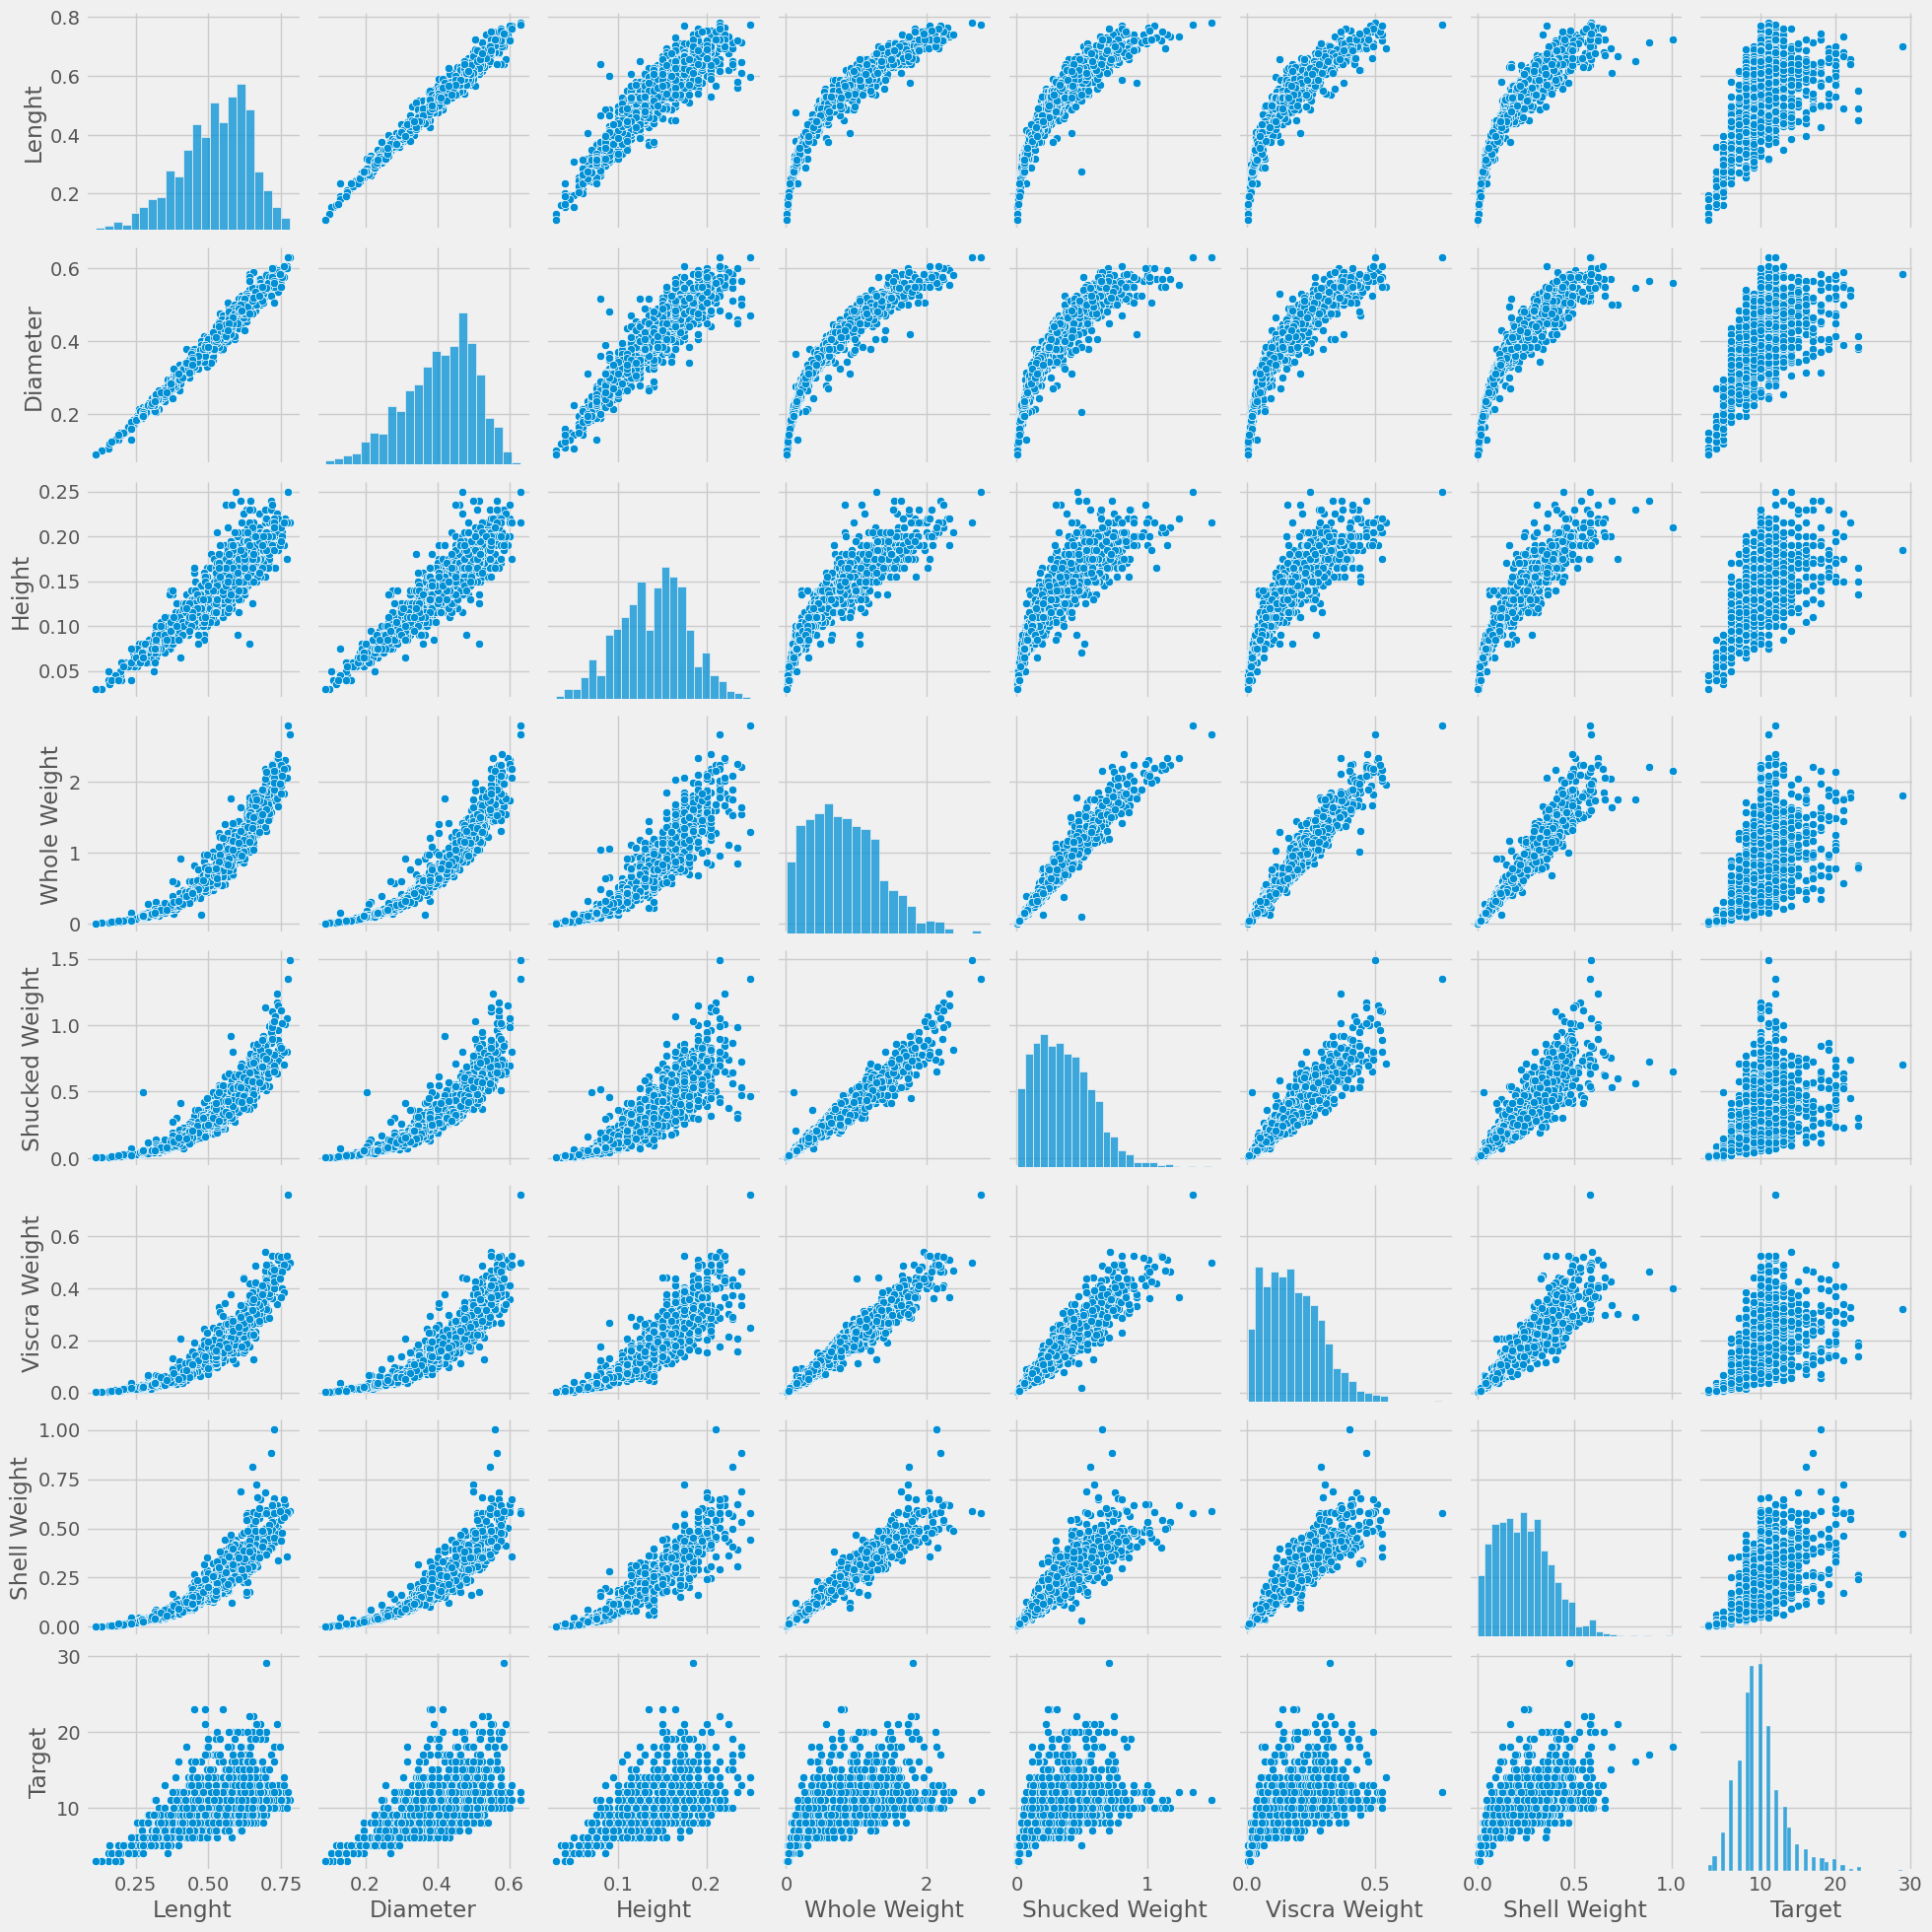

In [77]:
sns.pairplot(train[numerical_features])

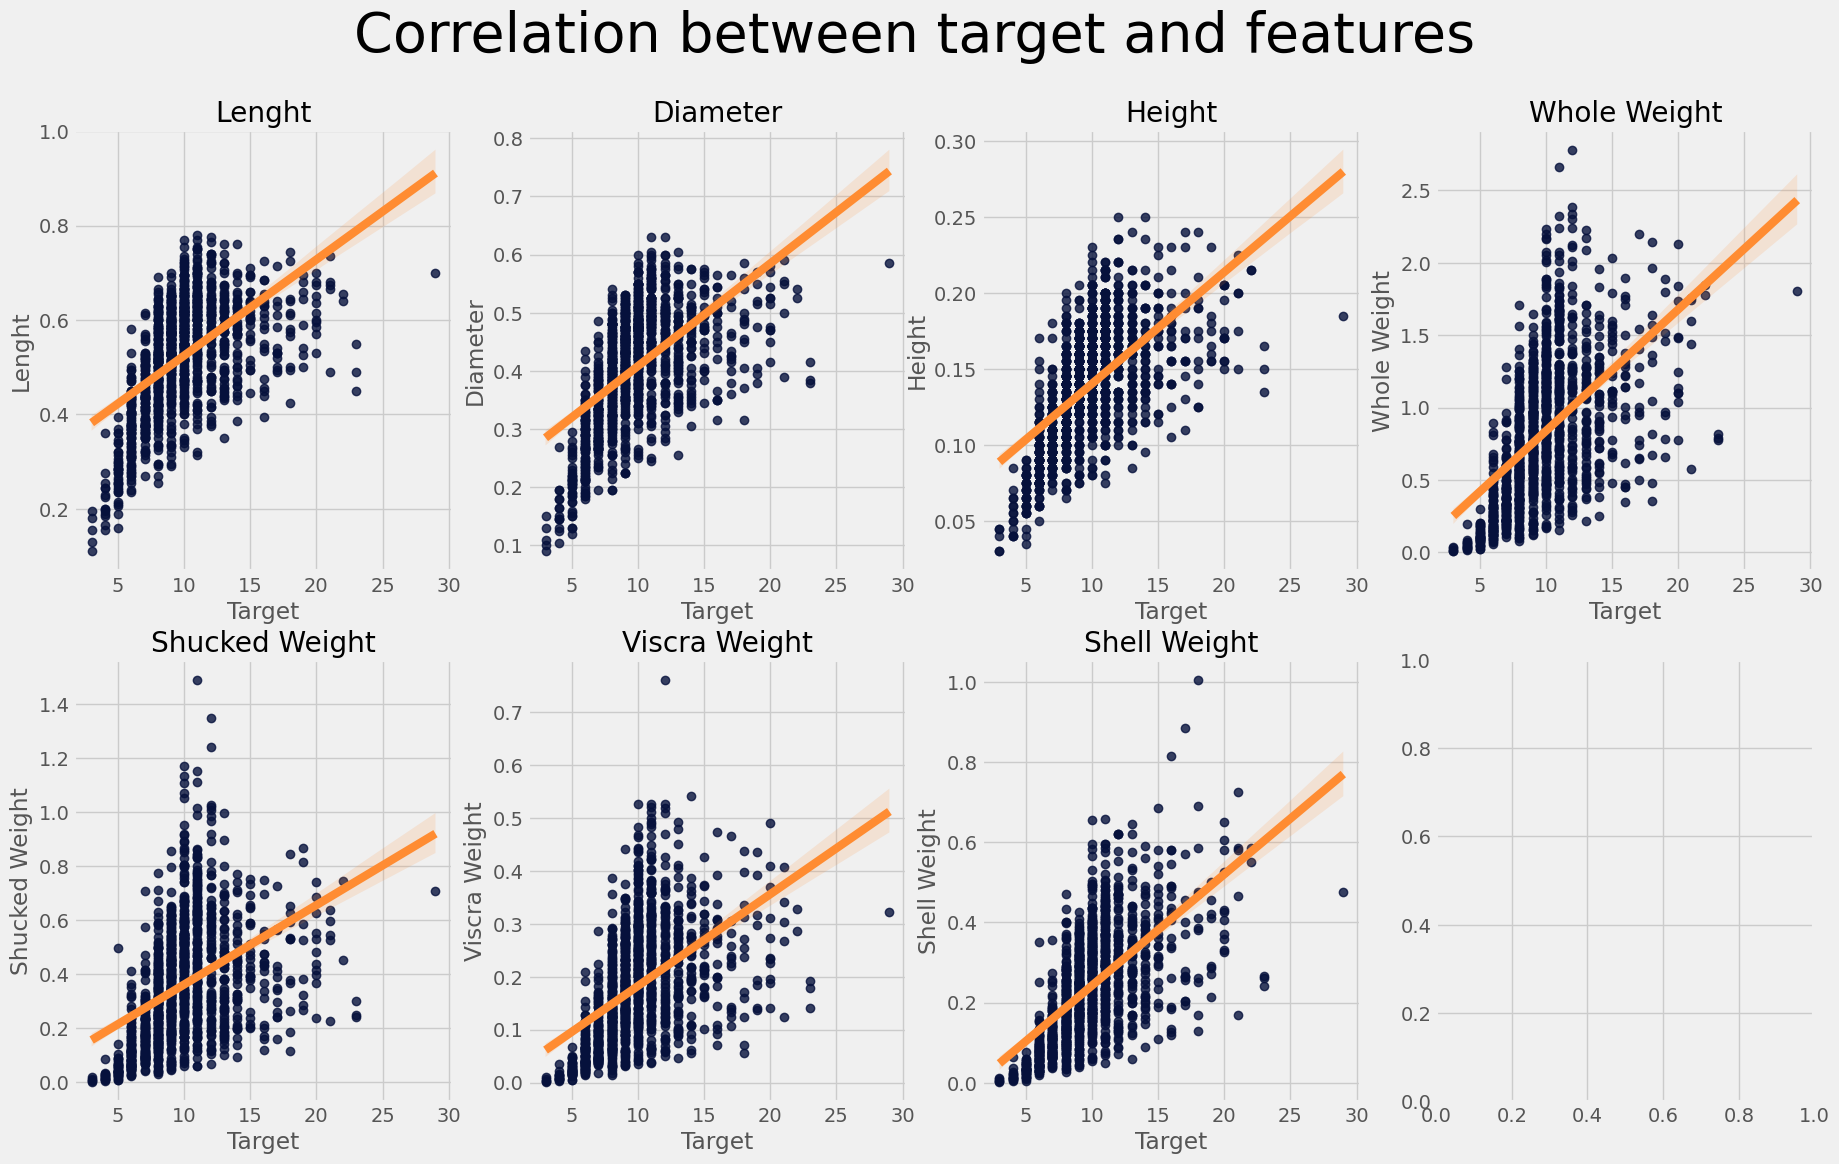

In [78]:
def visualize(axx, yfield):
  sns.regplot(x = 'Target', y=yfield, data=train, color = '#06113C', line_kws = {'color': '#FF8C32'}, ax = axx) #regplot을 이용해 추세선과 산점도 그래프를 그림
  axx.set_title(yfield)

figure, ((ax1, ax2, ax3, ax4),(ax5,ax6,ax7,ax8)) = plt.subplots(nrows =2,ncols =4)
figure.set_size_inches(20,12)
figure.suptitle('Correlation between target and features', fontsize = 40)
for i in range(len(train.columns[1:-1])): #column이 0부터 시작하면 gender도 포함하게 됨
  visualize(eval(f'ax{i+1}'), train.columns[i+1])

In [79]:
#pearson correlation analysis
#수치형 데이터 상관관계 히트맵 시각화
train_corr = train.drop(columns=['Gender'])
scaler = MinMaxScaler()
train_corr[train_corr.columns] = scaler.fit_transform(train_corr[train_corr.columns])
corr28 = train_corr.corr(method='pearson', numeric_only=True)

Text(0.5, 1.0, 'Correlation between features')

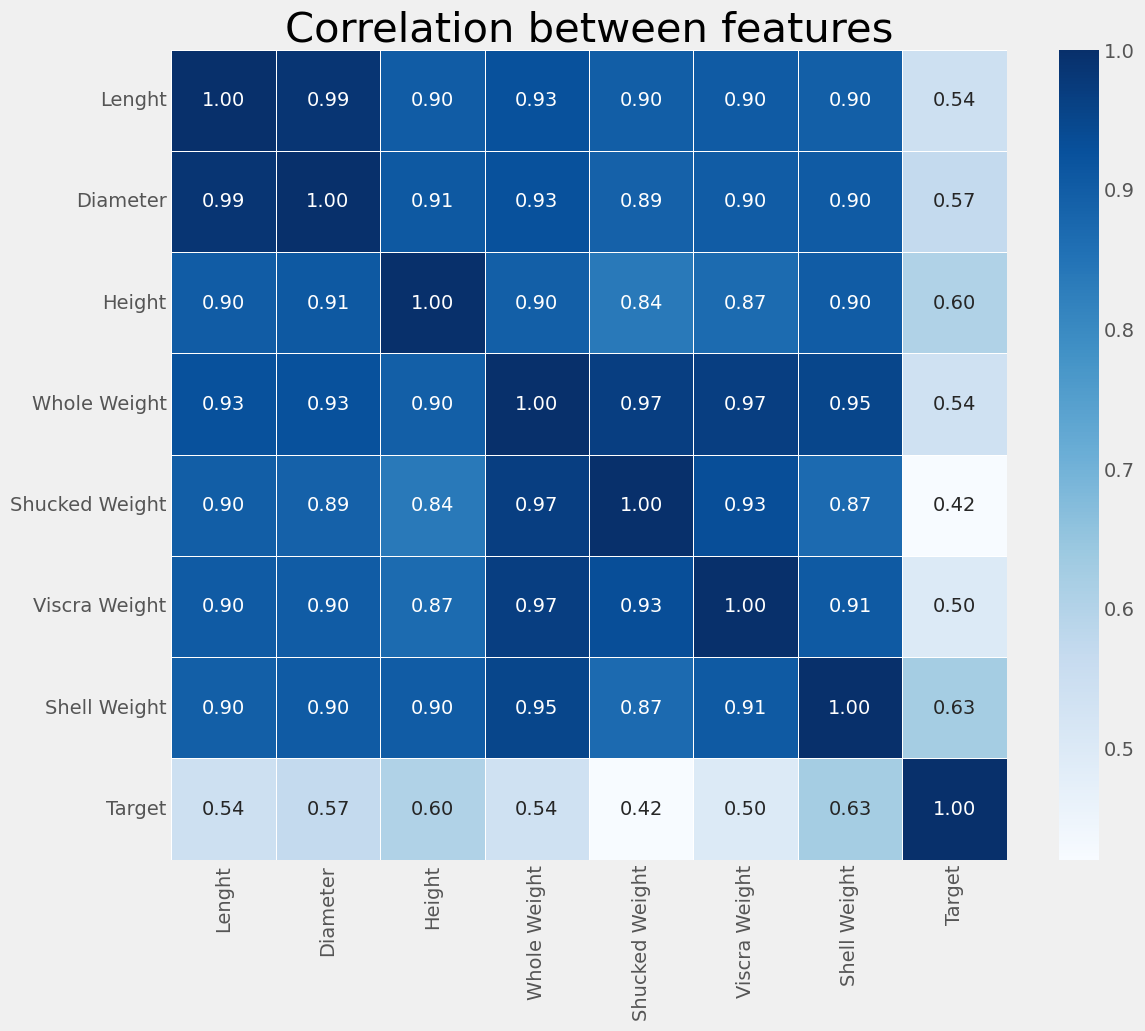

In [80]:
plt.figure(figsize = (12,10))
sns.heatmap(data = corr28, annot = True, fmt = '.2f', linewidths=.5, cmap = 'Blues')
plt.title('Correlation between features', fontsize = 30)

In [81]:
s28 = corr28.unstack()
df_temp28 = pd.DataFrame(s28['Target'].sort_values(ascending = False), columns = ['Target'])
df_temp28

,Target
Target,1.000000
Shell Weight,0.625819
Height,0.604654
Diameter,0.567933
Lenght,0.543789
Whole Weight,0.538404
Viscra Weight,0.497283
Shucked Weight,0.420126


In [82]:
a_train = train[train['Target']<10]

plt.figure(figsize = (12, 10))
corr = a_train.corr(method='pearson', numeric_only=True)

<Figure size 1200x1000 with 0 Axes>

Text(0.5, 1.0, 'Abalone < 10')

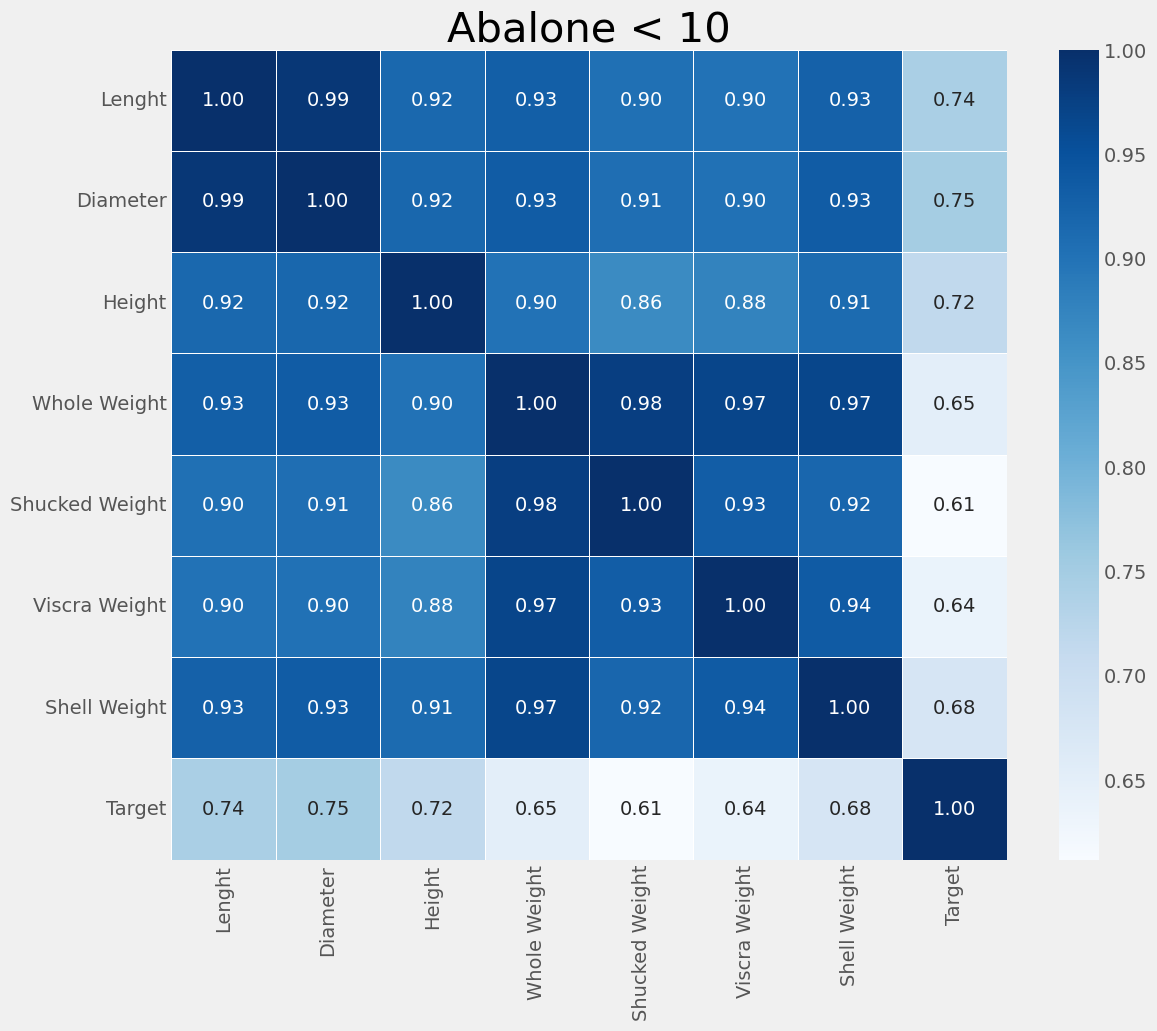

In [83]:
plt.figure(figsize = (12,10))
sns.heatmap(data = corr, annot = True, fmt = '.2f', linewidths=.5, cmap = 'Blues')
plt.title('Abalone < 10', fontsize = 30)

In [84]:
a_train = train[train['Target']>10]

plt.figure(figsize = (12, 10))
corr = a_train.corr(method='pearson', numeric_only=True)

<Figure size 1200x1000 with 0 Axes>

Text(0.5, 1.0, 'Abalone > 10')

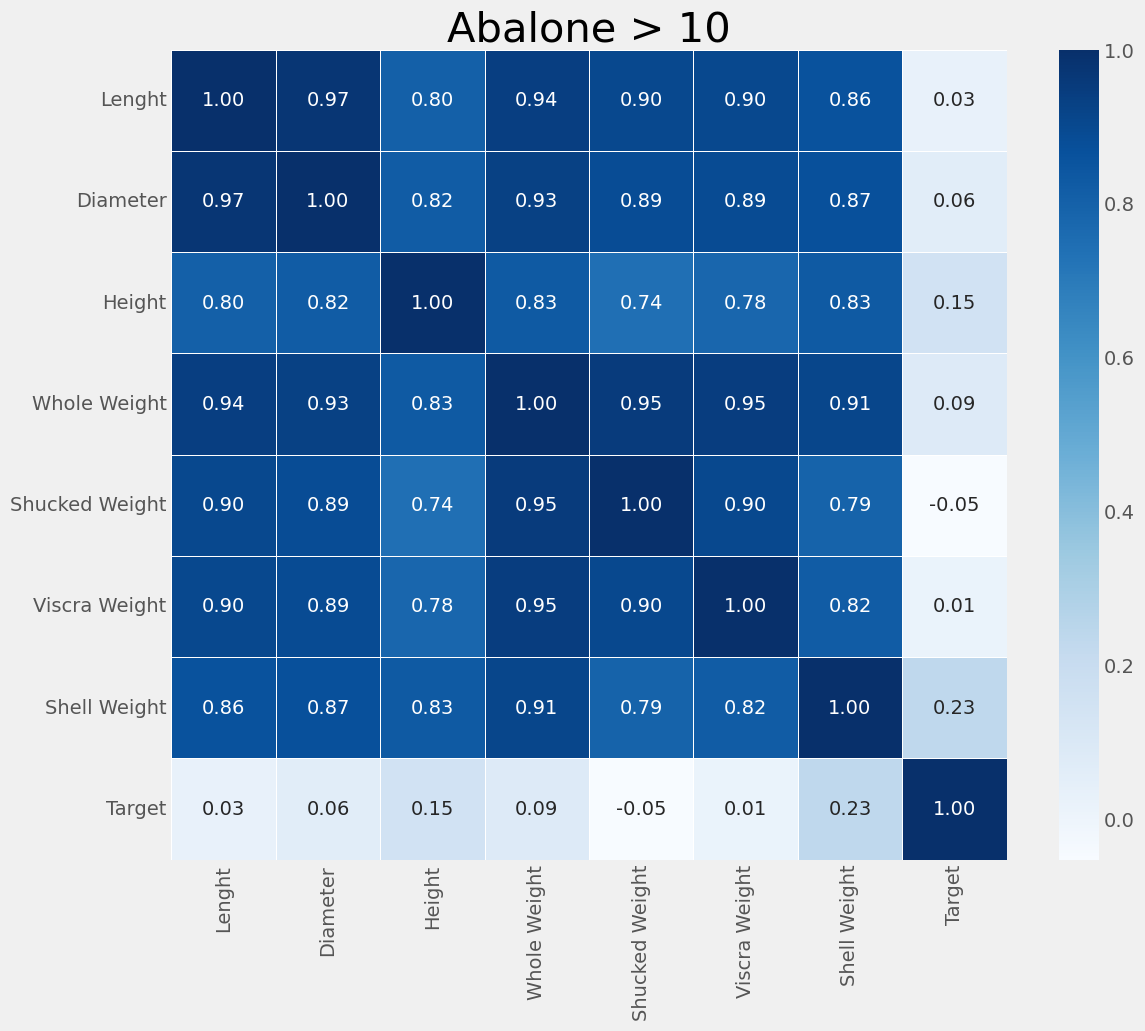

In [85]:
plt.figure(figsize = (12,10))
sns.heatmap(data = corr, annot = True, fmt = '.2f', linewidths=.5, cmap = 'Blues')
plt.title('Abalone > 10', fontsize = 30)

In [86]:
s = corr.unstack()
df_temp28 = pd.DataFrame(s['Target'].sort_values(ascending = False), columns = ['Target'])
df_temp28

,Target
Target,1.000000
Shell Weight,0.232080
Height,0.151197
Whole Weight,0.085100
Diameter,0.063892
Lenght,0.028679
Viscra Weight,0.013805
Shucked Weight,-0.053303


<Axes: xlabel='Gender', ylabel='Target'>

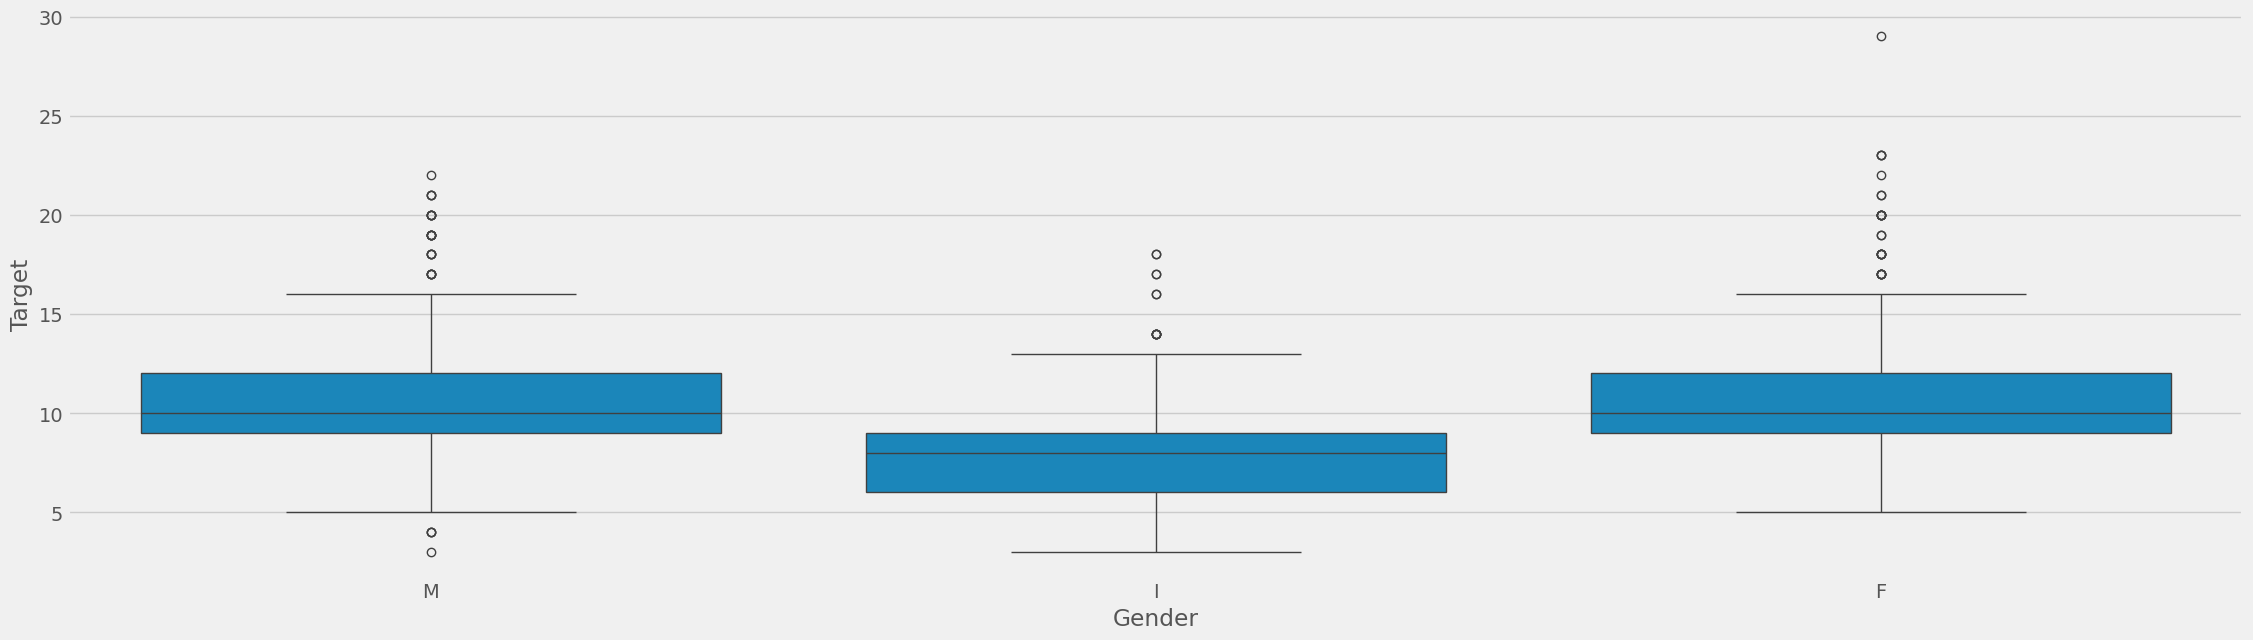

In [87]:
sns.boxplot(x = 'Gender', y = 'Target', data = train)

#EDA 요약
* 나이가 F, M, I 순으로 젊고
* target을 제외한 나머지 데이터들은 target과 선형적인 관계 while 10살

#Outlier 제거

<Axes: xlabel='Diameter', ylabel='Target'>

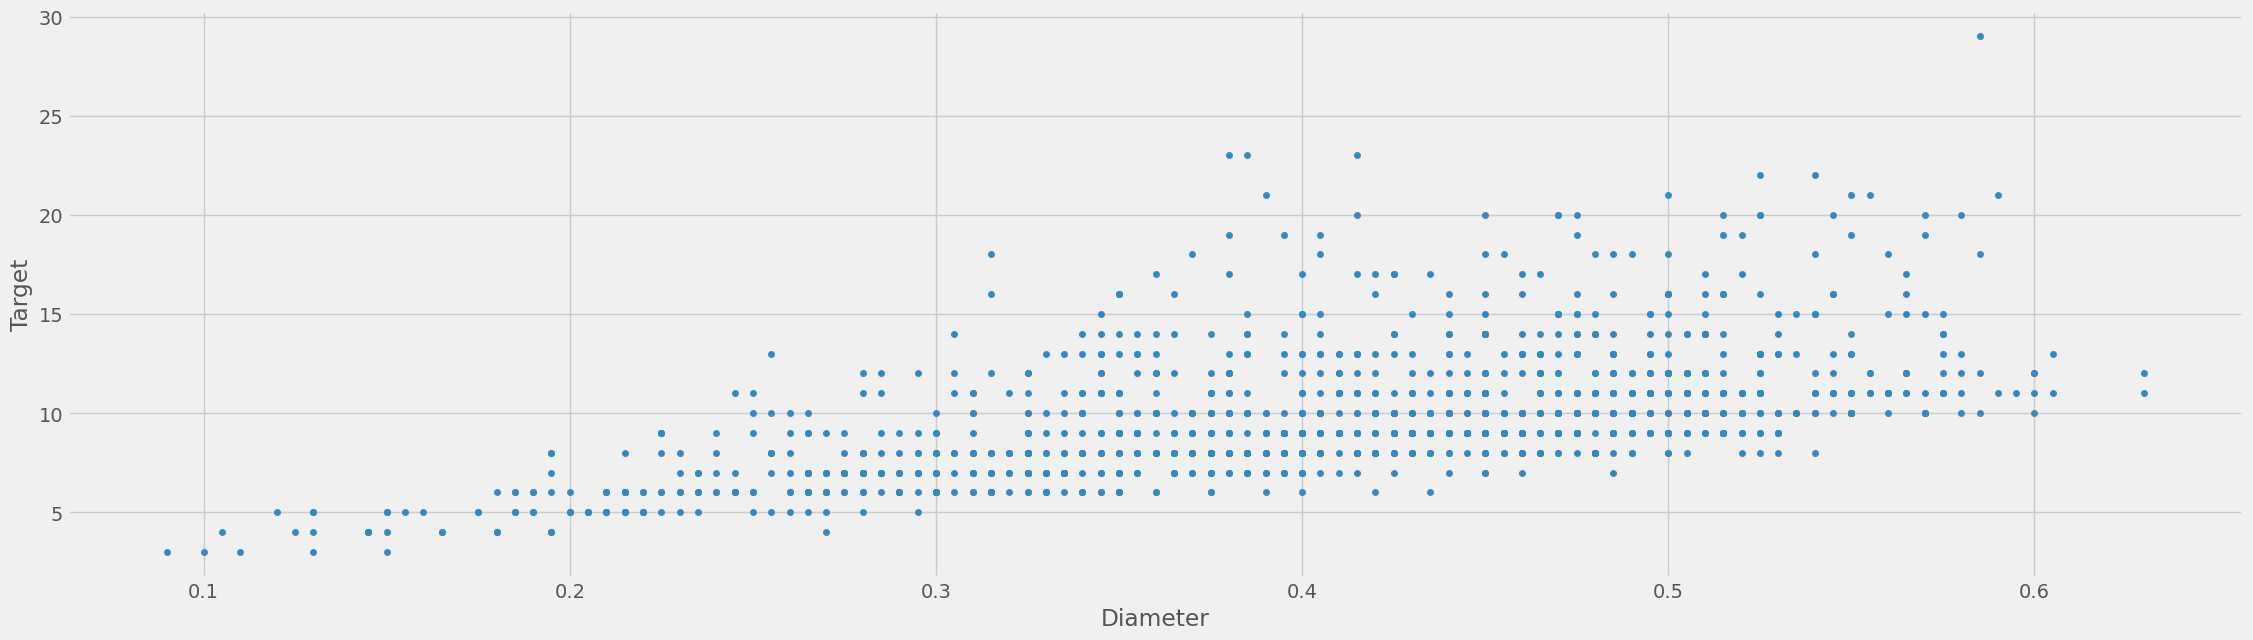

In [88]:
train_plot = pd.concat([train['Diameter'], train['Target']], axis=1)
train_plot.plot.scatter(x='Diameter', y ='Target')

<Axes: xlabel='Lenght', ylabel='Target'>

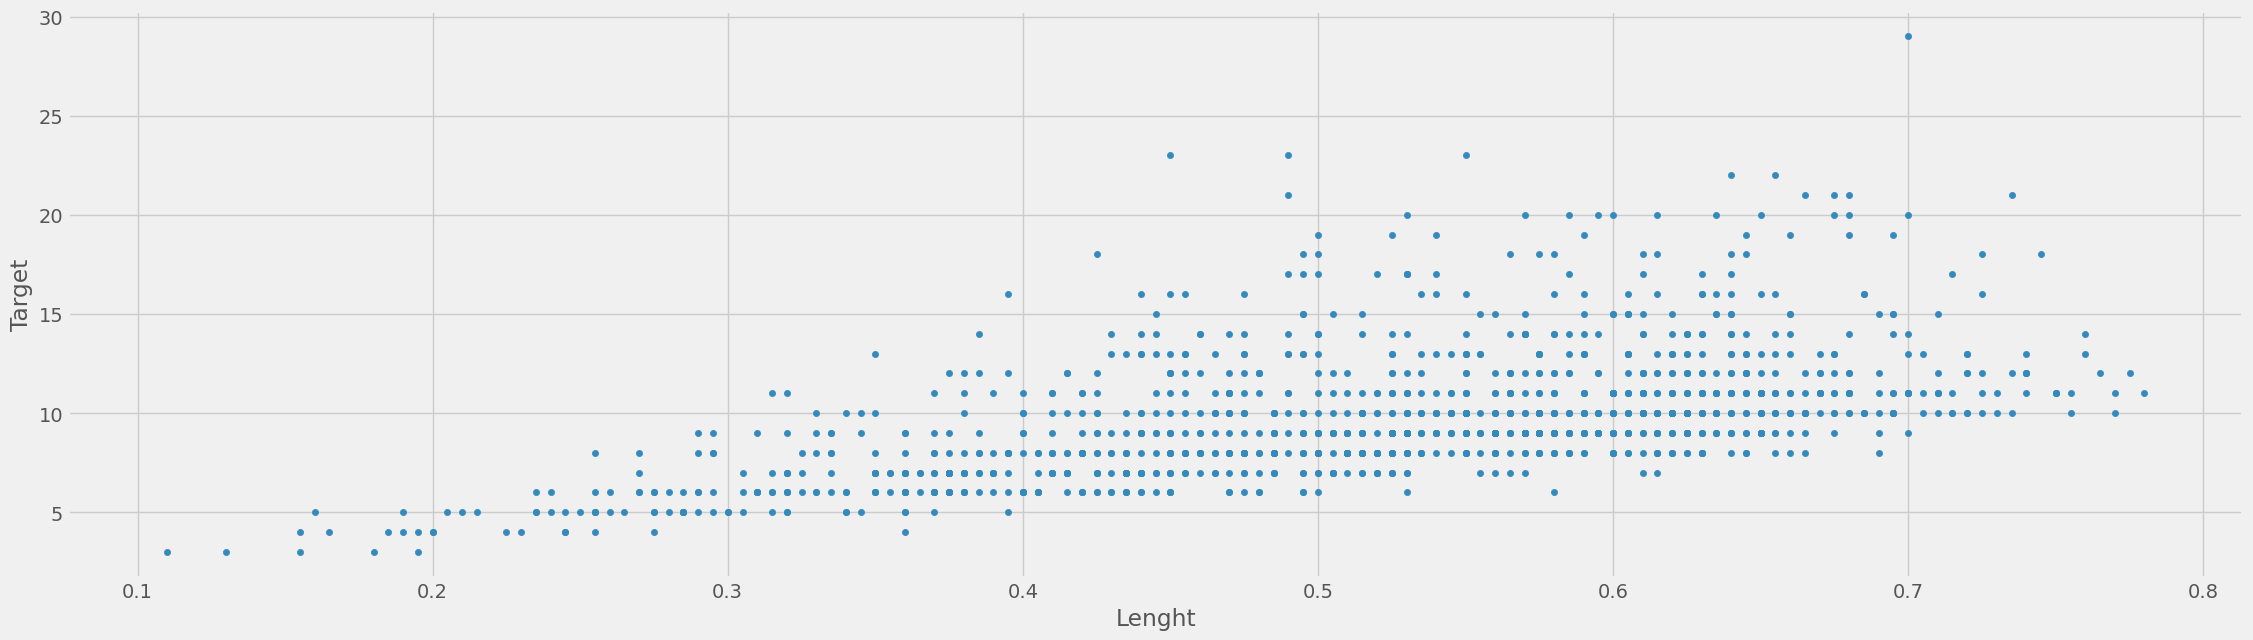

In [89]:
train_plot = pd.concat([train['Lenght'], train['Target']], axis=1)
train_plot.plot.scatter(x='Lenght', y ='Target')

<Axes: xlabel='Height', ylabel='Target'>

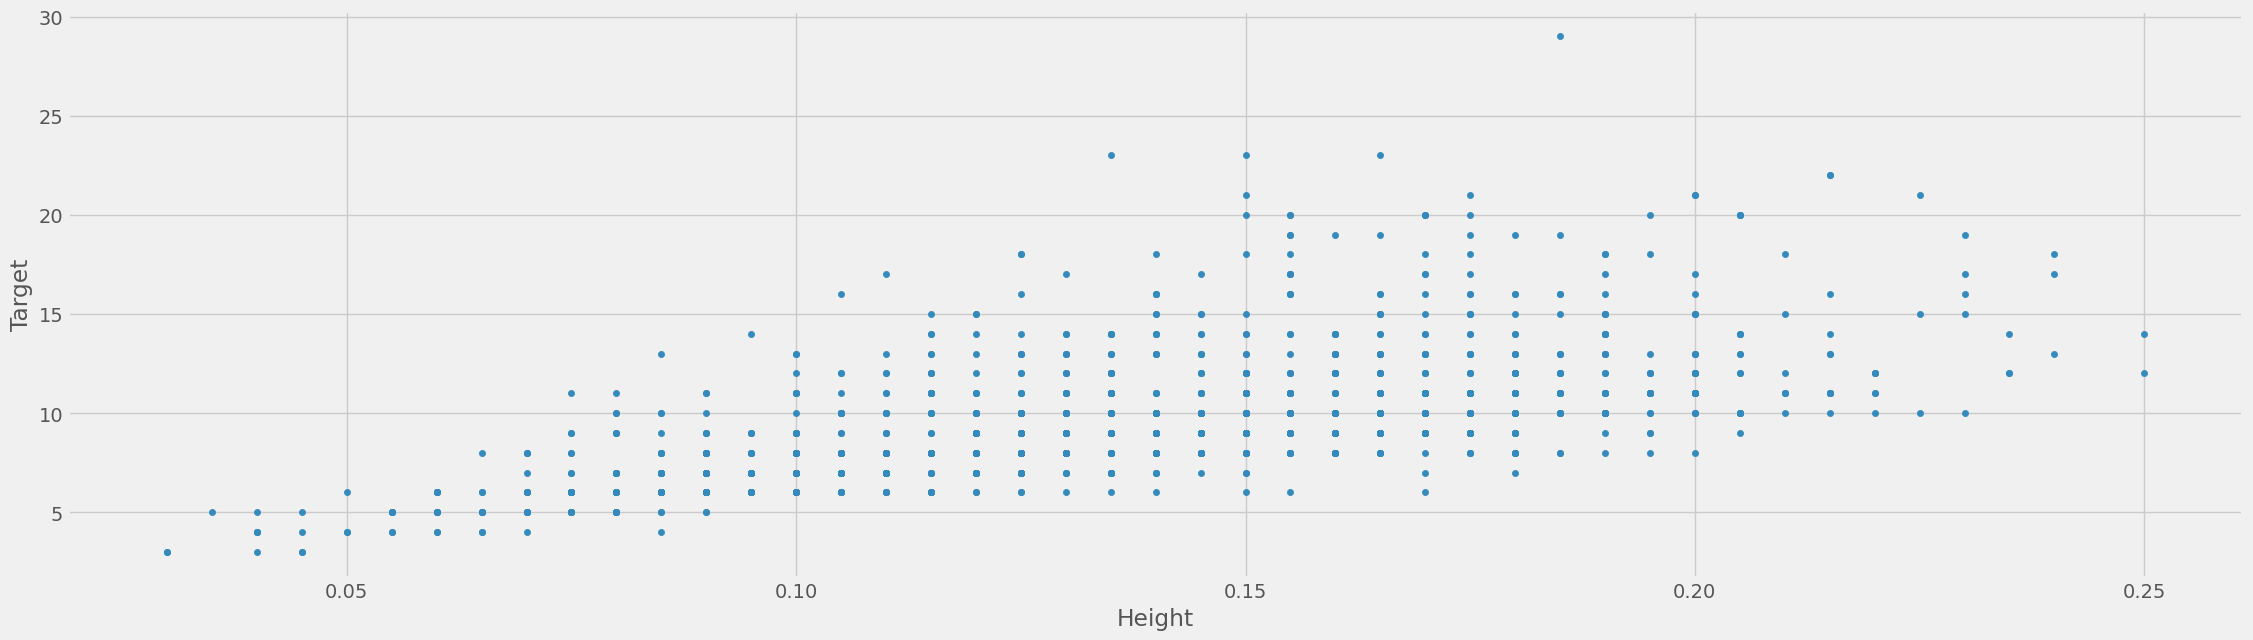

In [90]:
train_plot = pd.concat([train['Height'], train['Target']], axis=1)
train_plot.plot.scatter(x='Height', y ='Target')

<Axes: xlabel='Whole Weight', ylabel='Target'>

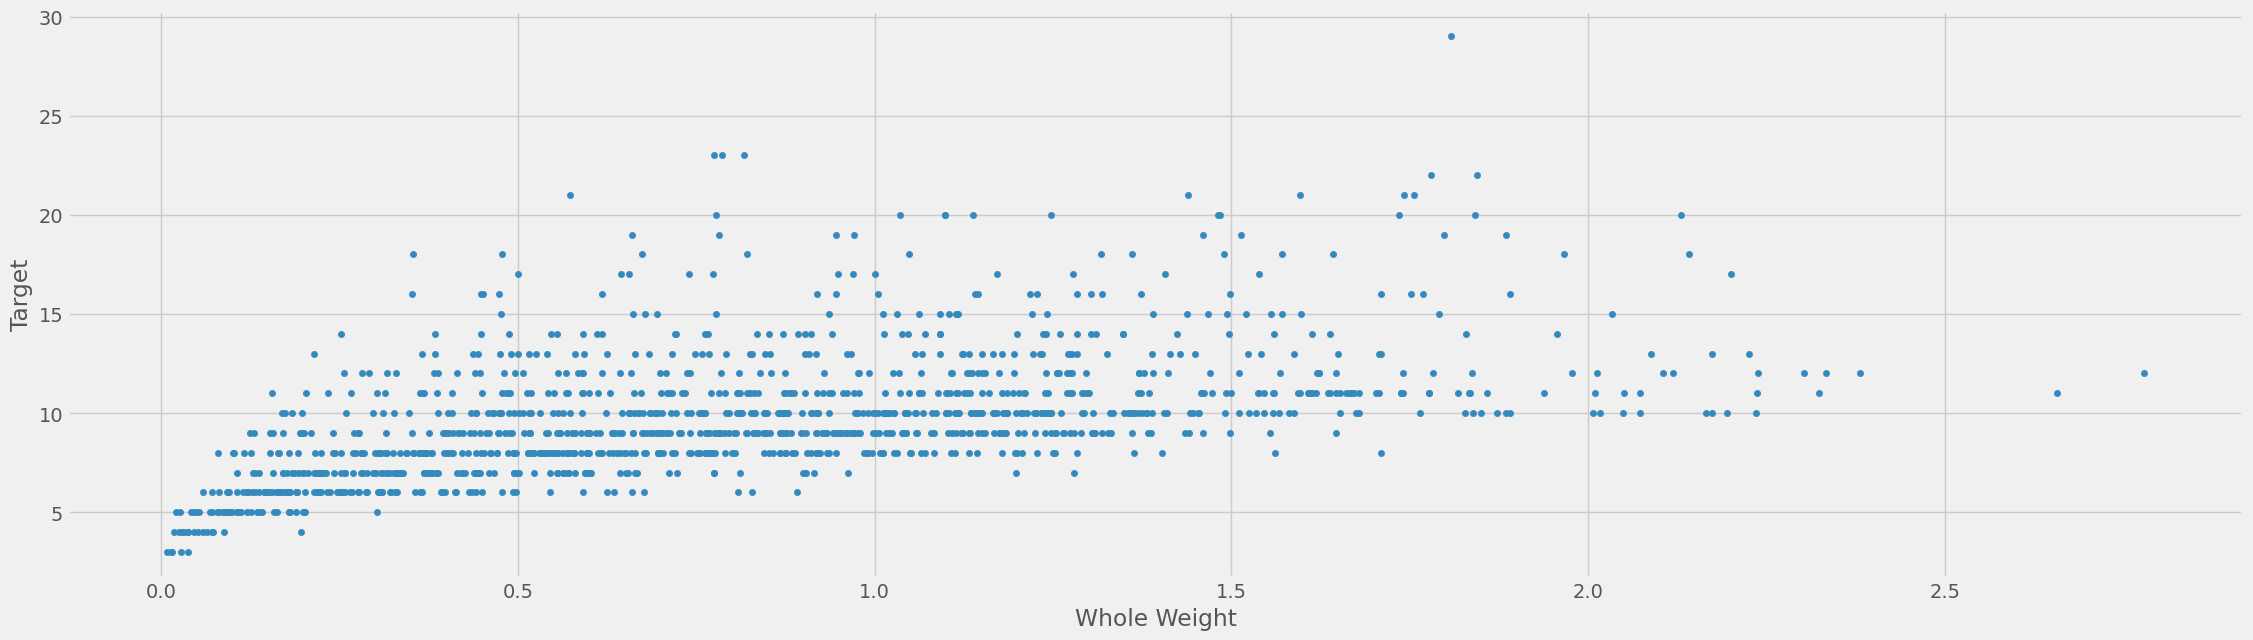

In [91]:
train_plot = pd.concat([train['Whole Weight'], train['Target']], axis=1)
train_plot.plot.scatter(x='Whole Weight', y ='Target')


In [92]:
train = train.drop(train[(train['Whole Weight']>2.5)].index)

<Axes: xlabel='Shucked Weight', ylabel='Target'>

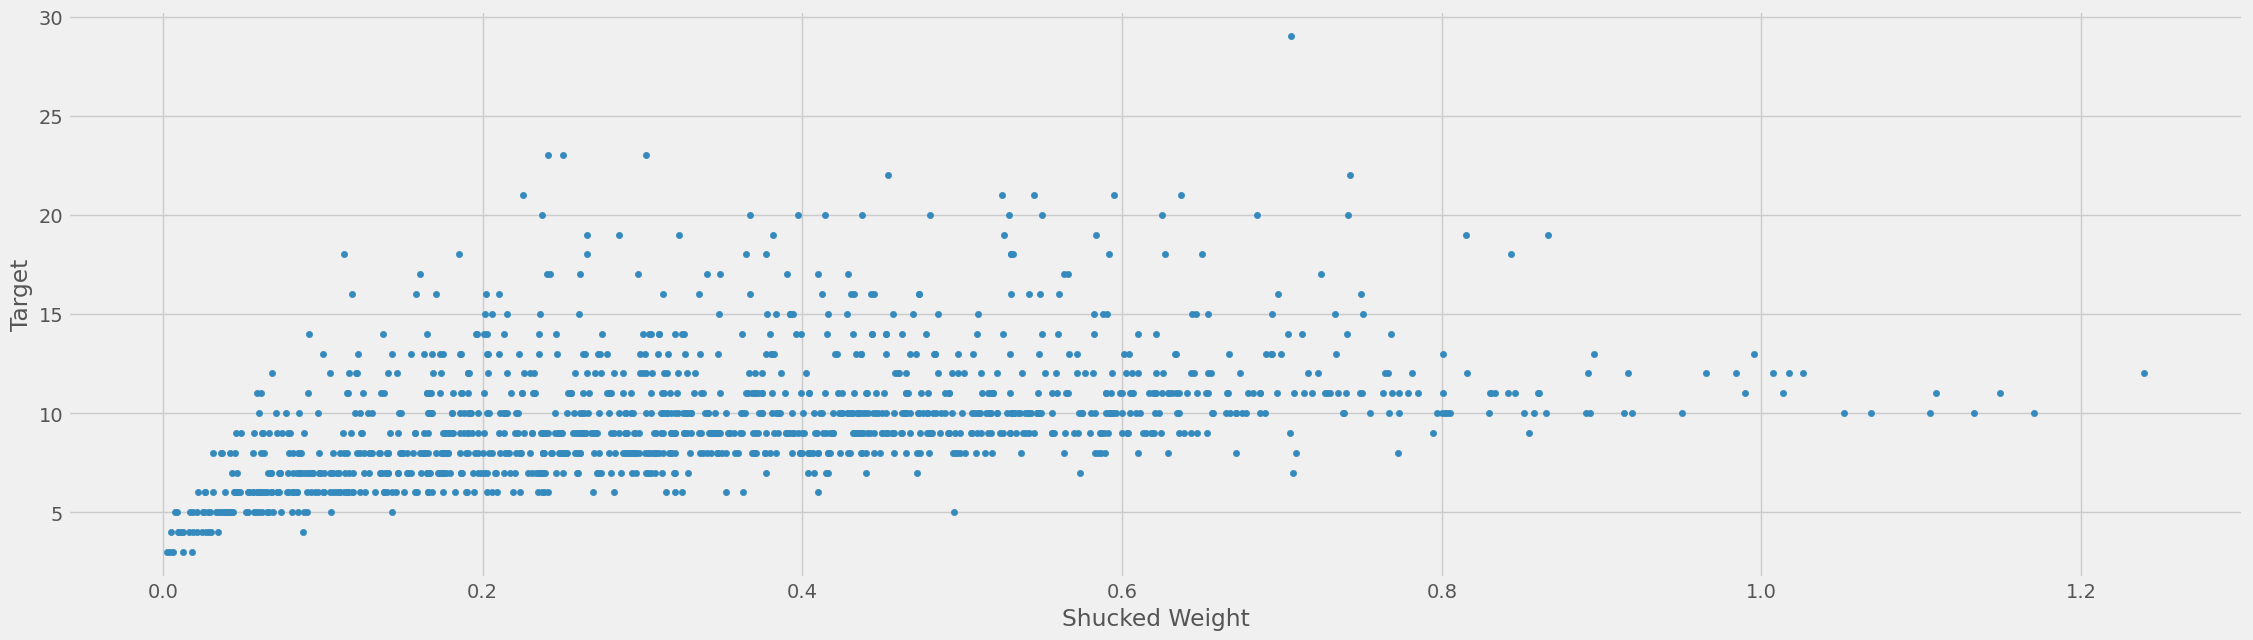

In [93]:
train_plot = pd.concat([train['Shucked Weight'], train['Target']], axis=1)
train_plot.plot.scatter(x='Shucked Weight', y ='Target')

In [94]:
train = train.drop(train[(train['Shucked Weight']>1.2)].index)

<Axes: xlabel='Viscra Weight', ylabel='Target'>

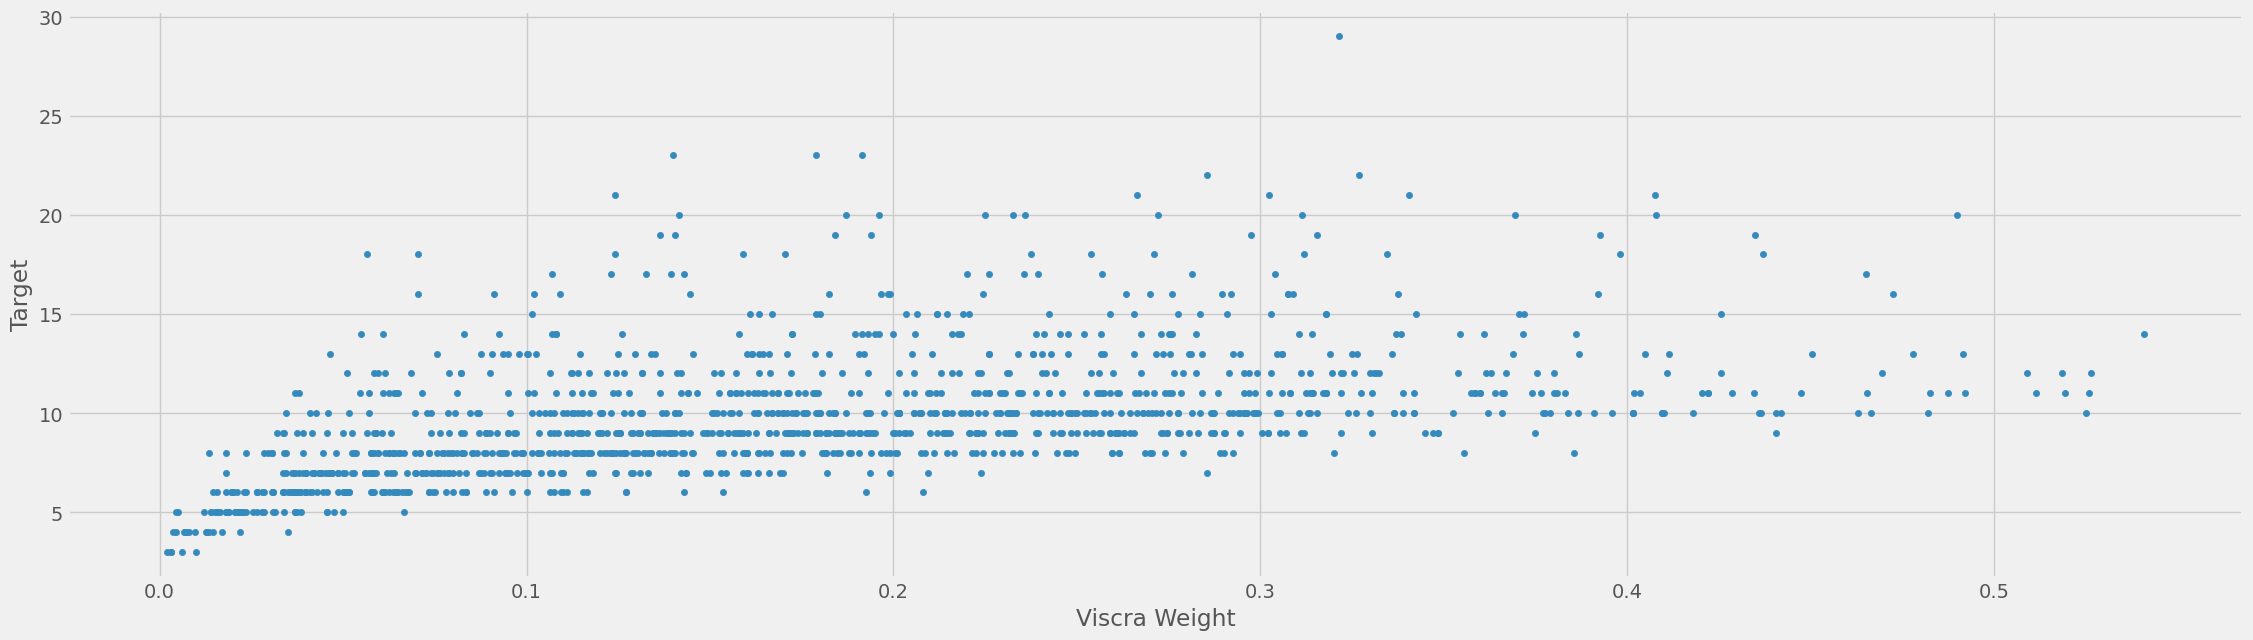

In [95]:
train_plot = pd.concat([train['Viscra Weight'], train['Target']], axis=1)
train_plot.plot.scatter(x='Viscra Weight', y ='Target')

<Axes: xlabel='Shell Weight', ylabel='Target'>

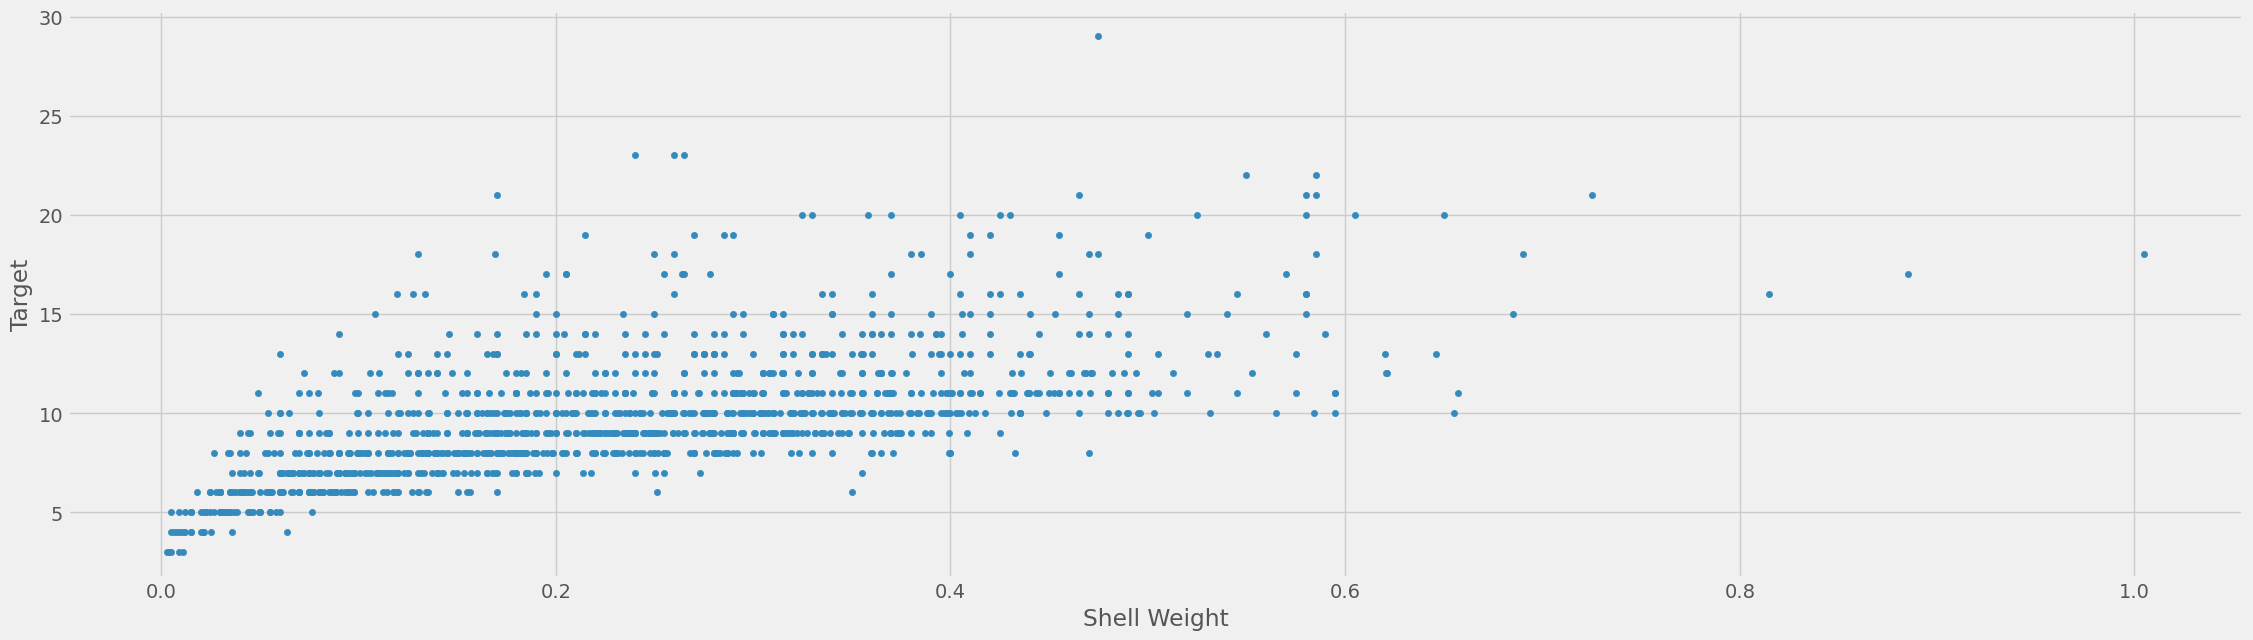

In [96]:
train_plot = pd.concat([train['Shell Weight'], train['Target']], axis=1)
train_plot.plot.scatter(x='Shell Weight', y ='Target')

In [97]:
# Feature Engineering 전 순수 Baseline (성별만 인코딩) 성능 평가
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# 원본 데이터의 복사본 생성하여 순수 baseline 테스트
df_base = train.copy()
df_base['Gender'] = LabelEncoder().fit_transform(df_base['Gender'])

X_base = df_base.drop('Target', axis=1)
y_base = df_base['Target']
xb_train, xb_test, yb_train, yb_test = train_test_split(X_base, y_base, random_state=10)

baseline_models = {
    'Baseline RandomForest': RandomForestRegressor(random_state=42),
    'Baseline GradientBoost': GradientBoostingRegressor(random_state=42),
    'Baseline XGBoost': xgb.XGBRegressor(random_state=42),
    'Baseline LightGBM': lgb.LGBMRegressor(random_state=42)
}

print("========== Feature Engineering 전 Baseline MAE ==========")
global baseline_mae_results
baseline_mae_results = {}
for name, model in baseline_models.items():
    model.fit(xb_train, yb_train)
    pred = model.predict(xb_test)
    mae = mean_absolute_error(yb_test, pred)
    baseline_mae_results[name] = mae
    print(f"{name} MAE: {mae:.4f}")


========== Feature Engineering 전 Baseline MAE ==========
Baseline RandomForest MAE: 1.5498
Baseline GradientBoost MAE: 1.5566
Baseline XGBoost MAE: 1.6787
Baseline LightGBM MAE: 1.6288


#모델 선정 (regressor)
* Random forest
* Gradient Boost
* XGBoost
* lightgbm


In [103]:
from IPython.display import display
# [포트폴리오 시각화 1] 물리적 모순 데이터 (Anomaly) 도출 과정 표 확인
# 전복의 전체 무게보다 부속(살, 내장, 껍질) 무게의 합이 더 커버리는 불가능한 데이터를 찾아냅니다.
anomaly_mask = train['Whole Weight'] < (train['Shucked Weight'] + train['Viscra Weight'] + train['Shell Weight'])
anomaly_df = train[anomaly_mask]

print(f"(부분 합 > 전체 범위) 레코드 수: {len(anomaly_df)}건")
display(anomaly_df.head(5).style.background_gradient(cmap='Reds', subset=['Whole Weight', 'Shucked Weight', 'Viscra Weight', 'Shell Weight']))


(부분 합 > 전체 범위) 레코드 수: 42건


,Gender,Lenght,Diameter,Height,Whole Weight,Shucked Weight,Viscra Weight,Shell Weight,Target
47,I,0.380000,0.275000,0.095000,0.137500,0.086000,0.058500,0.060500,7
119,I,0.375000,0.280000,0.080000,0.216500,0.093500,0.092500,0.070000,7
129,I,0.485000,0.365000,0.140000,0.447500,0.189500,0.092500,0.230500,8
179,I,0.215000,0.155000,0.060000,0.052500,0.021000,0.016500,0.015000,5
224,I,0.450000,0.335000,0.105000,0.447000,0.233500,0.153000,0.119000,7


## Advanced Data Preprocessing & Feature Engineering
- **Logical Anomaly Fix**: 'Whole Weight'가 부위합보다 적은 논리적 오류 데이터 강제 치환
- **Proportions & Density**: 노화와 직결된 껍질/살 비중 및 부피-밀도 추출


In [99]:
import numpy as np
import pandas as pd

def preprocessing_advanced(df):
    df_prep = df.copy()
    parts_sum = df_prep['Shucked Weight'] + df_prep['Viscra Weight'] + df_prep['Shell Weight']
    df_prep['Whole Weight'] = np.maximum(df_prep['Whole Weight'], parts_sum)
    df_prep['Water'] = np.clip(df_prep['Whole Weight'] - parts_sum, a_min=0, a_max=None)
    
    df_prep['Volume'] = df_prep['Lenght'] * df_prep['Diameter'] * df_prep['Height']
    df_prep['Aspect_Ratio'] = df_prep['Lenght'] / (df_prep['Diameter'] + 1e-8)
    df_prep['Density'] = df_prep['Whole Weight'] / (df_prep['Volume'] + 1e-8)
    df_prep['Shell_Ratio'] = df_prep['Shell Weight'] / (df_prep['Whole Weight'] + 1e-8)
    df_prep['Meat_Ratio'] = df_prep['Shucked Weight'] / (df_prep['Whole Weight'] + 1e-8)
    df_prep['Water_Ratio'] = df_prep['Water'] / (df_prep['Whole Weight'] + 1e-8)

    if 'Gender' in df_prep.columns:
        df_prep = pd.get_dummies(df_prep, columns=['Gender'], drop_first=False)
        for col in ['Gender_M', 'Gender_F', 'Gender_I']:
            if col in df_prep.columns:
                df_prep[col] = df_prep[col].astype(int)
                
    if 'id' in df_prep.columns:
        df_prep = df_prep.drop('id', axis=1)
    return df_prep

train_optimized = preprocessing_advanced(train)


## L1 Direct Optimization & OOF Ensemble
- 실험 결과: MSE(L2)를 타겟 로그 스케일링으로 잡는 것보다, **MAE(L1) 손실함수로 원본 원시 Target을 직접 타격하는 것**이 에러 하락에 압도적으로 강력했습니다.
- `np.log1p`를 폐기하고, 오롯이 `absolute_error` 손실함수로 세팅된 트리를 5-Fold로 학습시킵니다.


In [100]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

X = train_optimized.drop('Target', axis=1)
y = train_optimized['Target'] # RAW TARGET Use!

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_rfr = np.zeros(len(X))
oof_gbr = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))

# Optuna로 탐색된 L1 MAE 최적화 파라미터 적용
models = {
    'RFR': RandomForestRegressor(random_state=42, n_estimators=300, max_features='sqrt', max_depth=12, min_samples_split=5),
    'GBR': GradientBoostingRegressor(random_state=42, n_estimators=400, learning_rate=0.05, max_features=0.7, max_depth=5, loss='absolute_error'),
    'XGB': XGBRegressor(random_state=42, n_estimators=383, learning_rate=0.04, max_depth=4, subsample=0.75, colsample_bytree=0.64, objective='reg:absoluteerror'),
    'LGBM': LGBMRegressor(random_state=42, n_estimators=378, learning_rate=0.034, max_depth=8, num_leaves=29, subsample=0.86, colsample_bytree=0.72, objective='mae', verbose=-1)
}

print("========== 5-Fold Raw OOF Training ==========")
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train_f, X_val_f = X.iloc[train_idx], X.iloc[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
    
    models['RFR'].fit(X_train_f, y_train_f)
    oof_rfr[val_idx] = models['RFR'].predict(X_val_f)
    
    models['GBR'].fit(X_train_f, y_train_f)
    oof_gbr[val_idx] = models['GBR'].predict(X_val_f)
    
    models['XGB'].fit(X_train_f, y_train_f)
    oof_xgb[val_idx] = models['XGB'].predict(X_val_f)
    
    models['LGBM'].fit(X_train_f, y_train_f)
    oof_lgb[val_idx] = models['LGBM'].predict(X_val_f)

print("\n========== OOF MAE Results ==========")
print(f"RandomForest OOF MAE: {mean_absolute_error(y, oof_rfr):.4f}")
print(f"GradientBoost OOF MAE: {mean_absolute_error(y, oof_gbr):.4f}")
print(f"XGBoost OOF MAE: {mean_absolute_error(y, oof_xgb):.4f}")
print(f"LightGBM OOF MAE: {mean_absolute_error(y, oof_lgb):.4f}")


========== 5-Fold Raw OOF Training ==========

========== OOF MAE Results ==========
RandomForest OOF MAE: 1.5544
GradientBoost OOF MAE: 1.5305
XGBoost OOF MAE: 1.4960
LightGBM OOF MAE: 1.5323


In [101]:
import optuna
import optuna.visualization as vis
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# [포트폴리오 시각화 3] Optuna 하이퍼파라미터 베이지안 튜닝 과정 시각화 (포트폴리오 증빙용 단축 시연)
optuna.logging.set_verbosity(optuna.logging.WARNING)
X_demo, X_val_demo, y_demo, y_val_demo = train_test_split(X, y, test_size=0.2, random_state=42)

def objective_demo(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'objective': 'mae', 'verbose': -1
    }
    model = LGBMRegressor(**param, random_state=42)
    model.fit(X_demo, y_demo)
    return mean_absolute_error(y_val_demo, model.predict(X_val_demo))

print("포트폴리오용 Optuna 시각화 엔진 가동 중... (15 Trials)")
study = optuna.create_study(direction='minimize')
study.optimize(objective_demo, n_trials=15)

# Plotly 그래프 출력 (마우스 오버가 가능한 인터랙티브 플롯)
display(vis.plot_optimization_history(study))
display(vis.plot_param_importances(study))


포트폴리오용 Optuna 시각화 엔진 가동 중... (15 Trials)



Optimized Meta MAE (Raw): 1.4960
Optimized Meta MAE (Rounded Final): 1.4632


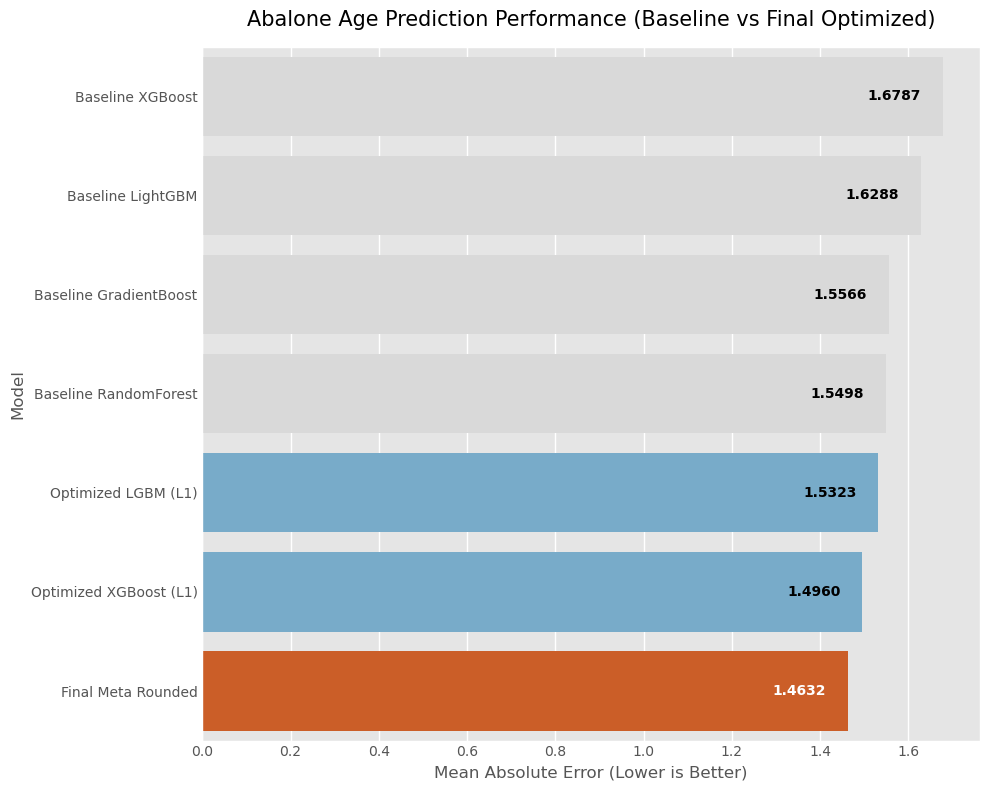

In [102]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

oof_preds = [oof_rfr, oof_gbr, oof_xgb, oof_lgb]
def objective(weights):
    wp = np.zeros(len(y))
    for w, p in zip(weights, oof_preds): wp += w * p
    return mean_absolute_error(y, wp)

cons = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1)] * 4
res = minimize(objective, [0.25]*4, method='SLSQP', bounds=bounds, constraints=cons)

final_oof_raw = np.zeros(len(y))
for w, p in zip(res.x, oof_preds): 
    final_oof_raw += w * p

# 핵심 트릭: 전복의 나이(Ring)는 무조건 '정수'이므로, 소수점 예측값에 존재하는 잔차항을 버리기 위해 Rounding 처리
final_oof_rounded = np.round(final_oof_raw)

optimized_mae_raw = mean_absolute_error(y, final_oof_raw)
optimized_mae_rounded = mean_absolute_error(y, final_oof_rounded)

print(f"\nOptimized Meta MAE (Raw): {optimized_mae_raw:.4f}")
print(f"Optimized Meta MAE (Rounded Final): {optimized_mae_rounded:.4f}")

plot_data = baseline_mae_results.copy()

plot_data.update({
    'Optimized LGBM (L1)': mean_absolute_error(y, oof_lgb),
    'Optimized XGBoost (L1)': mean_absolute_error(y, oof_xgb),
    'Final Meta Rounded': optimized_mae_rounded
})

vis_df = pd.DataFrame(list(plot_data.items()), columns=['Model', 'MAE']).sort_values(by='MAE', ascending=False)
plt.figure(figsize=(10, 8))
colors = ["#d9d9d9" if "Baseline" in x else "#6baed6" if "Optimized" in x else "#e6550d" for x in vis_df['Model']]
ax = sns.barplot(x='MAE', y='Model', data=vis_df, palette=colors)
plt.title('Abalone Age Prediction Performance (Baseline vs Final Optimized)', fontsize=15, pad=15)
plt.xlabel('Mean Absolute Error (Lower is Better)', fontsize=12)
for p in ax.patches:
    width = p.get_width()
    color = 'white' if width < 1.48 else 'black'
    plt.text(width - 0.05, p.get_y() + p.get_height() / 2., f'{width:.4f}', ha='right', va='center', fontsize=10, weight='bold', color=color)
plt.tight_layout()
plt.show()
